In [9]:
import os
import glob
import pickle
import traceback
import random
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.preprocessing import LabelEncoder

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report, balanced_accuracy_score,
    confusion_matrix, roc_auc_score
)

from imblearn.over_sampling import SMOTE

In [81]:
import pandas as pd

df_base = pd.read_excel('BASE_NEUROCOVID_FINALE_copy.xls')
print(df_base.head())

          IPP   N_PAT  SEXE        DDN  AGE  HTA  Diabète  Obésité   IMC  \
0  8005010327  8064.0     2 1969-12-31   50    0        0        1  34.5   
1  8013688574  8058.0     1 1956-09-06   64    1        0        0  23.0   
2  8001480966  8067.0     2 1954-02-12   66    1        1        0   NaN   
3  8004769613  8063.0     1 1959-08-31   61    1        0        1  32.5   
4  8004987536  8094.0     1 1949-10-07   70    1        1        1   NaN   

   BPCO /Iresp  ...  ECMO  Date ECMO  IRA.1 HDI           Date décès  \
0            0  ...     0        NaT      0   0                    0   
1            0  ...     0        NaT      0   0                    0   
2            0  ...     0        NaT      0   0                    0   
3            0  ...     0        NaT      1   0                    0   
4            0  ...     0        NaT      0   0  2020-09-21 00:00:00   

   Mortalité J28  Mortalité globale  Durée séjour réa  Durée S Hospi  \
0              1                  1   

In [83]:
print(df_base.columns.tolist())

['IPP', 'N_PAT', 'SEXE', 'DDN', 'AGE', 'HTA', 'Diabète', 'Obésité', 'IMC', 'BPCO /Iresp', 'IC', 'IRC', 'Cirrhose', 'Co mribidités', 'ImmunoD', 'Neuro', 'Confusion / RPM', 'GCS', 'Hyperthermie entrée', 'Anosmie /agueusie', 'Céphalées', 'IRA', 'Signes digestifs', 'IGS II', 'SF1', 'P/F initial', 'P/F min', 'Date admission réa', 'Date sortie réa ', 'Date EEG 1', 'Date EEG 2', 'Date EEG 3', 'Date EEG 4', 'EEG reactif stimuli SA et SN (oui 1, non 0, ne se prononce pas 3)', 'Réactivité  Auditive (oui1 non 0)', 'Reactivité Nociceptive (oui1 non 0)', 'EEG activité de fond (continue 0 discontinue 1)', 'Suppression Burst (oui 1 non 0)', 'Rythme de fond Min (C/S)', 'Rythme de fond Max (c/s)', 'EEG Asymétrie (oui 1 non 0)', 'Tracé plat (oui 1 non 0)', 'EEG figures épileptiques (aucune 0 généralisées 1 Focales 2)', 'Figures du sommeil (oui 1 non 0)', 'Complexes K (oui1 non 0)', 'Fuseaux de sommeil (oui 1 non 0)', 'Complexes Lents périodiques (oui 1 non 0)', 'CL périodiques (non 0, focaux 1 généralis

In [20]:
print(len(df_base))

134


In [21]:
folder = r'C:\abalaji\EEG_bichat\ORIGINAL_DATA'
import os

file_names = os.listdir(folder)

valid_ids = set()
for f in file_names:
    name = os.path.splitext(f)[0]
    try:
        valid_ids.add(int(name))
    except ValueError:
        pass

print(f"Found {len(valid_ids)} valid file IDs")

Found 101 valid file IDs


In [23]:
valid_ids_str = set([os.path.splitext(f)[0] for f in os.listdir(folder_path)])  # already strings
n_pat_ids_str = set(
    df_base['N_PAT']
    .dropna()
    .astype('Int64')
    .astype(str)
)

in_both        = valid_ids_str & n_pat_ids_str
in_folder_only = valid_ids_str - n_pat_ids_str
in_df_only     = n_pat_ids_str - valid_ids_str

print(f"Matched (in both):             {len(in_both)}")
print(f"In folder but not in df_base:  {len(in_folder_only)}")
print(f"In df_base but not in folder:  {len(in_df_only)}")

print(f"\nOnly in folder (no match in df_base): {sorted(in_folder_only)}")
print(f"\nOnly in df_base (no file in folder):  {sorted(in_df_only)}")

diff1 = n_pat_ids_str - valid_ids_str  # in df not in folder
diff2 = valid_ids_str - n_pat_ids_str  # in folder not in df
print(f"\nIDs in df_base but not folder: {sorted(diff1)}")
print(f"IDs in folder but not df_base: {sorted(diff2)}")

print(f"\nIn folder not in df: {sorted(valid_ids_str - n_pat_ids_str)}")
print(f"In df not in folder: {sorted(n_pat_ids_str - valid_ids_str)}")

Matched (in both):             98
In folder but not in df_base:  3
In df_base but not in folder:  2

Only in folder (no match in df_base): ['5939', '8541', '8948']

Only in df_base (no file in folder):  ['5039', '8581']

IDs in df_base but not folder: ['5039', '8581']
IDs in folder but not df_base: ['5939', '8541', '8948']

In folder not in df: ['5939', '8541', '8948']
In df not in folder: ['5039', '8581']


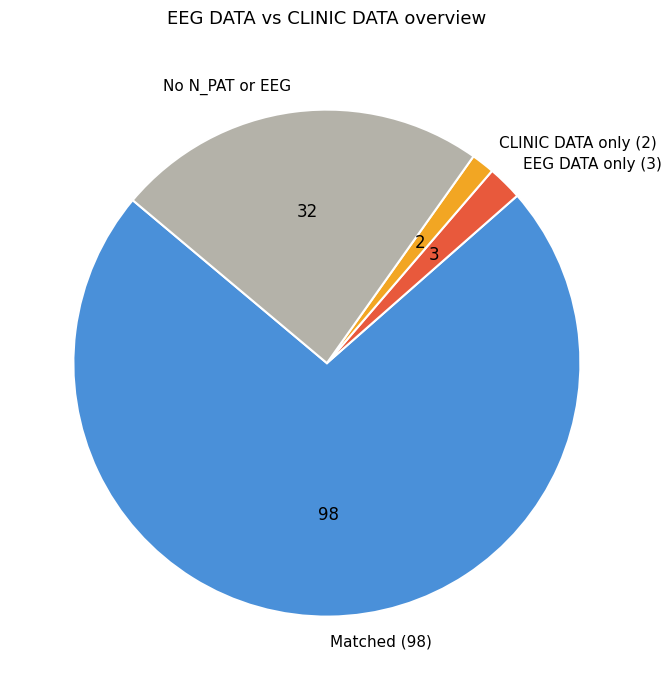

Saved to: C:\abalaji\bichat\results\DATA_ANALYSIS\eeg_npat_overview.png


In [85]:
import matplotlib.pyplot as plt

# Values
matched        = 98
in_folder_only = 3
in_df_only     = 2
no_npat_or_eeg = 135 - 98 - 3 - 2

labels = ['Matched (98)', 'EEG DATA only (3)', 'CLINIC DATA only (2)', 'No N_PAT or EEG']
sizes  = [98, 3, 2, no_npat_or_eeg]
colors = ['#4A90D9', '#E8593C', '#F2A623', '#B4B2A9']

filtered = [(l, s, c) for l, s, c in zip(labels, sizes, colors) if s > 0]
labels, sizes, colors = zip(*filtered)

fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct=lambda p: f'{int(round(p * sum(sizes) / 100))}',
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)

for t in texts:
    t.set_color('black')       # <-- label text in black
    t.set_fontsize(11)

for t in autotexts:
    t.set_color('black')       # <-- percentage text in black
    t.set_fontsize(12)

ax.set_title("EEG DATA vs CLINIC DATA overview", fontsize=13, pad=16, color='black')

plt.tight_layout()

output_path = r'C:\abalaji\bichat\results\DATA_ANALYSIS\eeg_npat_overview.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved to: {output_path}")

In [38]:
in_both = valid_ids_str & n_pat_ids_str

df_matched = df_base[
    df_base['N_PAT'].astype('Int64').astype(str).isin(in_both)
]

print(f"Matched samples: {len(df_matched)}")
print(df_matched.head())

Matched samples: 98
          IPP   N_PAT  SEXE        DDN  AGE  HTA  Diabète  Obésité   IMC  \
0  8005010327  8064.0     2 1969-12-31   50    0        0        1  34.5   
1  8013688574  8058.0     1 1956-09-06   64    1        0        0  23.0   
2  8001480966  8067.0     2 1954-02-12   66    1        1        0   NaN   
3  8004769613  8063.0     1 1959-08-31   61    1        0        1  32.5   
4  8004987536  8094.0     1 1949-10-07   70    1        1        1   NaN   

   BPCO /Iresp  ...  ECMO  Date ECMO  IRA.1 HDI           Date décès  \
0            0  ...     0        NaT      0   0                    0   
1            0  ...     0        NaT      0   0                    0   
2            0  ...     0        NaT      0   0                    0   
3            0  ...     0        NaT      1   0                    0   
4            0  ...     0        NaT      0   0  2020-09-21 00:00:00   

   Mortalité J28  Mortalité globale  Durée séjour réa  Durée S Hospi  \
0              1  

In [39]:
print(len(df_matched))

98


In [40]:
mask = (df_matched['Mortalité J28'] == 1) & (df_matched['Mortalité globale'] == 0)

print(f"Samples before removal: {len(df_matched)}")
df_matched = df_matched[~mask]
print(f"Samples after removal:  {len(df_matched)}")

Samples before removal: 98
Samples after removal:  97


In [45]:
print(df_matched.head())

          IPP   N_PAT  SEXE        DDN  AGE  HTA  Diabète  Obésité   IMC  \
0  8005010327  8064.0     2 1969-12-31   50    0        0        1  34.5   
1  8013688574  8058.0     1 1956-09-06   64    1        0        0  23.0   
2  8001480966  8067.0     2 1954-02-12   66    1        1        0   NaN   
3  8004769613  8063.0     1 1959-08-31   61    1        0        1  32.5   
4  8004987536  8094.0     1 1949-10-07   70    1        1        1   NaN   

   BPCO /Iresp  ...  ECMO  Date ECMO  IRA.1 HDI           Date décès  \
0            0  ...     0        NaT      0   0                    0   
1            0  ...     0        NaT      0   0                    0   
2            0  ...     0        NaT      0   0                    0   
3            0  ...     0        NaT      1   0                    0   
4            0  ...     0        NaT      0   0  2020-09-21 00:00:00   

   Mortalité J28  Mortalité globale  Durée séjour réa  Durée S Hospi  \
0              1                  1   

In [46]:
missing = pd.DataFrame({
    'Missing Count': df_matched.isna().sum(),
    'Missing %': (df_matched.isna().sum() / len(df_matched) * 100).round(2)
})

missing = missing[missing['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print(f"Total rows: {len(df_matched)}\n")
print(missing.to_string())

Total rows: 97

                           Missing Count  Missing %
Valeur NSE 7 (µg/l)                   97     100.00
Date NSE 6                            97     100.00
Valeur NSE 6                          97     100.00
Date NSE 7                            97     100.00
Durée ECMO                            96      98.97
Date ECMO                             96      98.97
Date EEG 4                            96      98.97
Date EEG 3                            96      98.97
Val Pup 2 OD                          94      96.91
Valeur PS100 6     (µg/l)             93      95.88
Date PS100 6                          93      95.88
Date Pup 2                            93      95.88
Val Pup 2 OG                          93      95.88
Date EEG 2                            92      94.85
DATE NSE 5                            87      89.69
Valeur NSE 5 (µg/L)                   87      89.69
Valeur PS 100 5  (µg/l)               85      87.63
Date PS100 5                          85      87

In [49]:
cols_to_drop = missing.index.tolist()
df_matched = df_matched.drop(columns=cols_to_drop)

print(f"\nDropped {len(cols_to_drop)} columns: {cols_to_drop}")
print(f"Remaining columns: {df_matched.shape[1]}")
print(df_matched.columns.tolist())


Dropped 42 columns: ['Valeur NSE 7 (µg/l)', 'Date NSE 6', 'Valeur NSE 6', 'Date NSE 7', 'Durée ECMO', 'Date ECMO', 'Date EEG 4', 'Date EEG 3', 'Val Pup 2 OD', 'Valeur PS100 6     (µg/l)', 'Date PS100 6 ', 'Date Pup 2', 'Val Pup 2 OG', 'Date EEG 2', 'DATE NSE 5', 'Valeur NSE 5 (µg/L)', 'Valeur PS 100 5  (µg/l)', 'Date PS100 5', 'Date VM', 'DATE NSE 4', 'Valeur NSE 4 (µg/L)', 'Valeur PS100 4 (µg/l)', 'Date PS 100 4 ', 'Valeur pup 1 OD', 'VALEUR NSE 3 (µg/L)', 'DATE NSE 3', 'Valeur PS100 3 (µg/l)', 'Date PS100 3', 'Valeur puillo 1 OG (%)', 'Date pup 1', 'DATE NSE 2 ', 'Valeur NSE 2 (µg/L)', 'Date PS100 2', 'Valeur PS 100 2 (µg/l)', 'Valeur NSE 1 (µg/L)', 'DATE NSE 1', 'P/F min', 'P/F initial', 'IMC', 'Valeur PS 100 1 (µg/l)', 'Date PS100 1', 'Co mribidités']
Remaining columns: 55
['IPP', 'N_PAT', 'SEXE', 'DDN', 'AGE', 'HTA', 'Diabète', 'Obésité', 'BPCO /Iresp', 'IC', 'IRC', 'Cirrhose', 'ImmunoD', 'Neuro', 'Confusion / RPM', 'GCS', 'Hyperthermie entrée', 'Anosmie /agueusie', 'Céphalées', 

In [50]:
print(df_matched.shape)

(97, 55)


In [51]:
print(df_matched.head())


          IPP   N_PAT  SEXE        DDN  AGE  HTA  Diabète  Obésité  \
0  8005010327  8064.0     2 1969-12-31   50    0        0        1   
1  8013688574  8058.0     1 1956-09-06   64    1        0        0   
2  8001480966  8067.0     2 1954-02-12   66    1        1        0   
3  8004769613  8063.0     1 1959-08-31   61    1        0        1   
4  8004987536  8094.0     1 1949-10-07   70    1        1        1   

   BPCO /Iresp  IC  ...  VM  Durée VM (jours)  ECMO  IRA.1  HDI  \
0            0   0  ...   1                 1     0      0    0   
1            0   0  ...   0                 0     0      0    0   
2            0   0  ...   0                 0     0      0    0   
3            0   0  ...   0                 0     0      1    0   
4            0   0  ...   0                 0     0      0    0   

            Date décès  Mortalité J28  Mortalité globale  Durée séjour réa  \
0                    0              1                  1                 8   
1                   

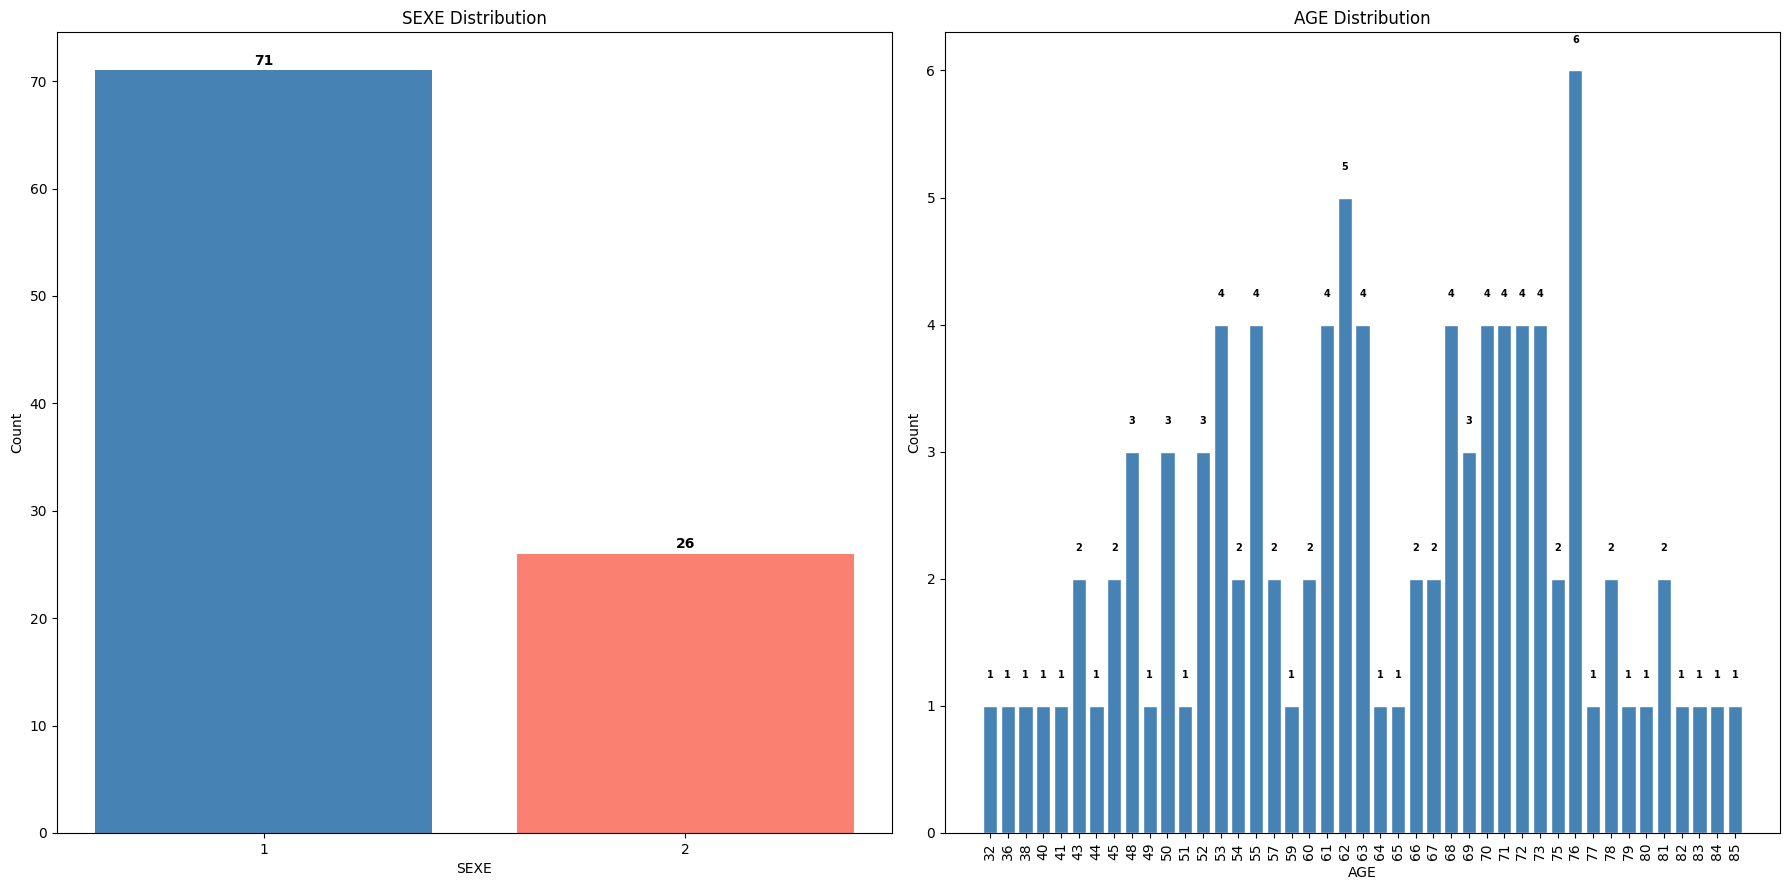

In [86]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))
fig.patch.set_facecolor('white')

# --- SEXE ---
ax1.set_facecolor('white')
sexe_counts = df_matched['SEXE'].value_counts()
ax1.bar(sexe_counts.index.astype(str), sexe_counts.values, color=['steelblue', 'salmon'])
ax1.set_title('SEXE Distribution', color='black')
ax1.set_xlabel('SEXE', color='black')
ax1.set_ylabel('Count', color='black')
ax1.tick_params(colors='black')
for spine in ax1.spines.values():
    spine.set_edgecolor('black')
for i, v in enumerate(sexe_counts.values):
    ax1.text(i, v + 0.5, str(v), ha='center', fontweight='bold', color='black')

# --- AGE ---
ax2.set_facecolor('white')
age_counts = df_matched['AGE'].dropna().astype(int).value_counts().sort_index()
bars = ax2.bar(age_counts.index.astype(str), age_counts.values, color='steelblue', edgecolor='white')
ax2.set_title('AGE Distribution', color='black')
ax2.set_xlabel('AGE', color='black')
ax2.set_ylabel('Count', color='black')
ax2.tick_params(axis='x', rotation=90, colors='black')
ax2.tick_params(axis='y', colors='black')
for spine in ax2.spines.values():
    spine.set_edgecolor('black')
for bar, v in zip(bars, age_counts.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             str(v), ha='center', va='bottom', fontsize=7, fontweight='bold', color='black')

output_path = r'C:\abalaji\bichat\results\DATA_ANALYSIS\sex_age_Distribution.png'
plt.tight_layout()
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

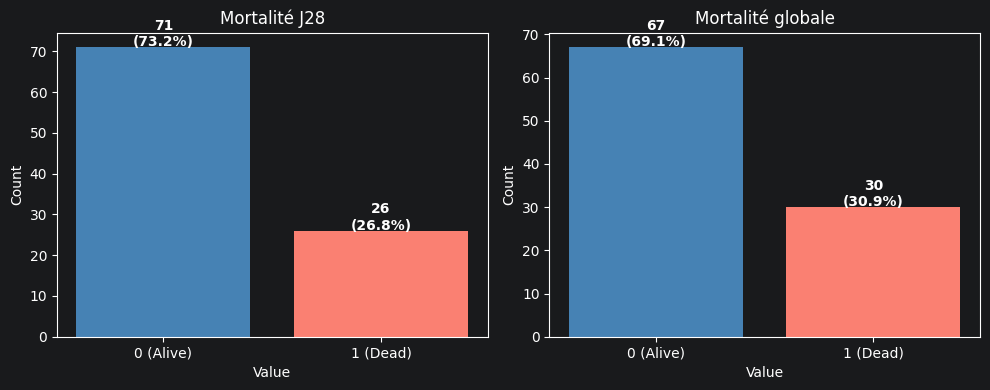

In [54]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col in zip(axes, ['Mortalité J28', 'Mortalité globale']):
    counts = df_matched[col].value_counts().sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values, color=['steelblue', 'salmon'])
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['0 (Alive)', '1 (Dead)'])
    for bar, v in zip(bars, counts.values):
        pct = round(v / len(df_matched) * 100, 1)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v}\n({pct}%)', ha='center', fontweight='bold')

plt.tight_layout()
output_path = r'C:\abalaji\bichat\results\DATA_ANALYSIS\Mortalité.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

In [59]:
in_28Days   = ((df_matched['Mortalité J28'] == 1) & (df_matched['Mortalité globale'] == 1)).sum()
total_death  = (df_matched['Mortalité globale'] == 1).sum()
after_28Days = total_death - in_28Days
alive        = (df_matched['Mortalité globale'] == 0).sum()

print(f"Total samples:          {len(df_matched)}")
print(f"Total deaths:           {total_death}")
print(f"  - Died within 28 days:  {in_28Days}")
print(f"  - Died after 28 days:   {after_28Days}")
print(f"Alive:                  {alive}")

Total samples:          97
Total deaths:           30
  - Died within 28 days:  26
  - Died after 28 days:   4
Alive:                  67


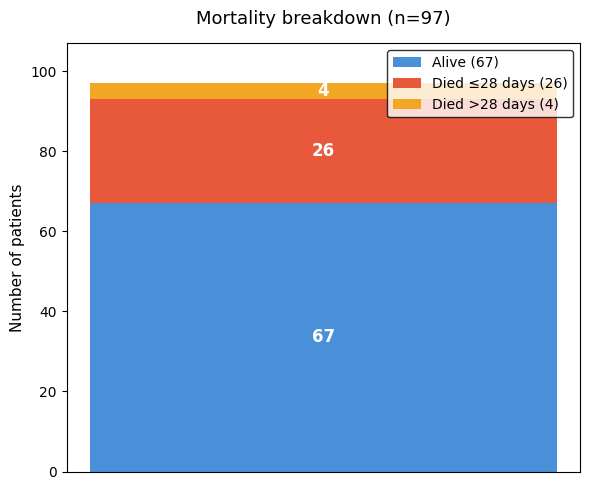

Saved to: C:\abalaji\bichat\results\DATA_ANALYSIS\mortality_breakdown.png


In [87]:
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bar_width = 0.2
x = [0]

p1 = ax.bar(x, alive,        bar_width, label=f'Alive ({alive})',                color='#4A90D9')
p2 = ax.bar(x, in_28Days,    bar_width, label=f'Died ≤28 days ({in_28Days})',    color='#E8593C', bottom=alive)
p3 = ax.bar(x, after_28Days, bar_width, label=f'Died >28 days ({after_28Days})', color='#F2A623', bottom=alive + in_28Days)

# Add value labels inside bars
ax.text(0, alive / 2,                            str(alive),        ha='center', va='center', fontsize=12, color='white', fontweight='bold')
ax.text(0, alive + in_28Days / 2,                str(in_28Days),    ha='center', va='center', fontsize=12, color='white', fontweight='bold')
ax.text(0, alive + in_28Days + after_28Days / 2, str(after_28Days), ha='center', va='center', fontsize=12, color='white', fontweight='bold')

ax.set_xticks([])
ax.set_ylabel('Number of patients', fontsize=11, color='black')
ax.set_title(f'Mortality breakdown (n={len(df_matched)})', fontsize=13, pad=14, color='black')
ax.tick_params(colors='black')
ax.legend(loc='upper right', fontsize=10, facecolor='white', edgecolor='black', labelcolor='black')
ax.set_ylim(0, alive + in_28Days + after_28Days + 10)
for spine in ax.spines.values():
    spine.set_edgecolor('black')

plt.tight_layout()
output_path = r'C:\abalaji\bichat\results\DATA_ANALYSIS\mortality_breakdown.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved to: {output_path}")

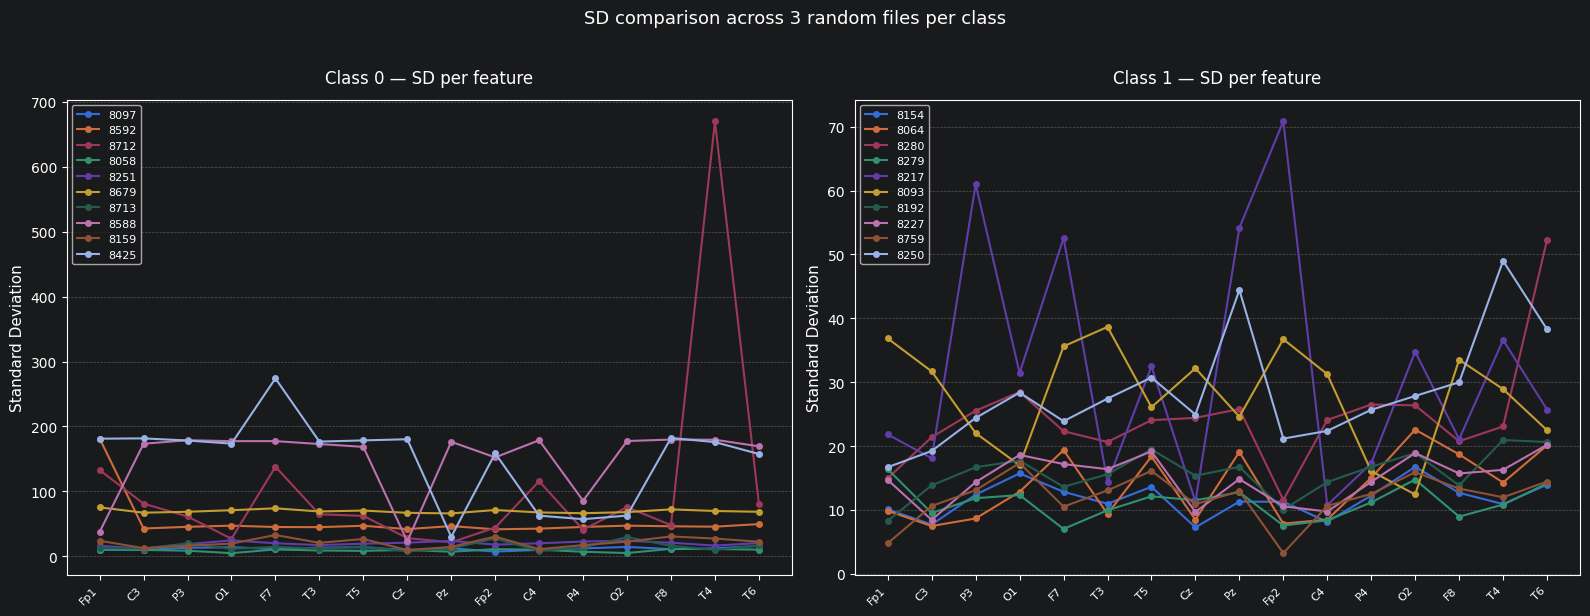

Saved to: C:\abalaji\bichat\results\DATA_ANALYSIS\sd_comparison_classes1.png


In [74]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Paths
path_0 = r'C:\abalaji\bichat\eeg_csv\0'
path_1 = r'C:\abalaji\bichat\eeg_csv\1'

# Select random 3 from each
random.seed(10)
sample_0 = random.sample(os.listdir(path_0), 10)
sample_1 = random.sample(os.listdir(path_1), 10)

def get_sd(folder, files):
    sd_dict = {}
    for f in files:
        df = pd.read_csv(os.path.join(folder, f))
        # Drop time columns
        time_cols = [col for col in df.columns if 'time' in col.lower()]
        df = df.drop(columns=time_cols)
        sd_dict[f] = df.std()
    return sd_dict

sd_0 = get_sd(path_0, sample_0)
sd_1 = get_sd(path_1, sample_1)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)


for ax, sd_dict, title in zip(
    axes,
    [sd_0, sd_1],
    ['Class 0 — SD per feature', 'Class 1 — SD per feature']
):
    for i, (fname, sd_vals) in enumerate(sd_dict.items()):
        ax.plot(sd_vals.index, sd_vals.values,
                label=os.path.splitext(fname)[0],
                linewidth=1.5,
                marker='o',
                markersize=4)

    ax.set_xticks(range(len(sd_vals.index)))
    ax.set_xticklabels(sd_vals.index, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Standard Deviation', fontsize=11)
    ax.set_title(title, fontsize=12, pad=12)
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('SD comparison across 3 random files per class', fontsize=13, y=1.02)
plt.tight_layout()

output_path = r'C:\abalaji\bichat\results\DATA_ANALYSIS\sd_comparison_classes1.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to: {output_path}")

Channels found: ['Fp1', 'C3', 'P3', 'O1', 'F7', 'T3', 'T5', 'Cz', 'Pz', 'Fp2', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6']
Number of channels: 16


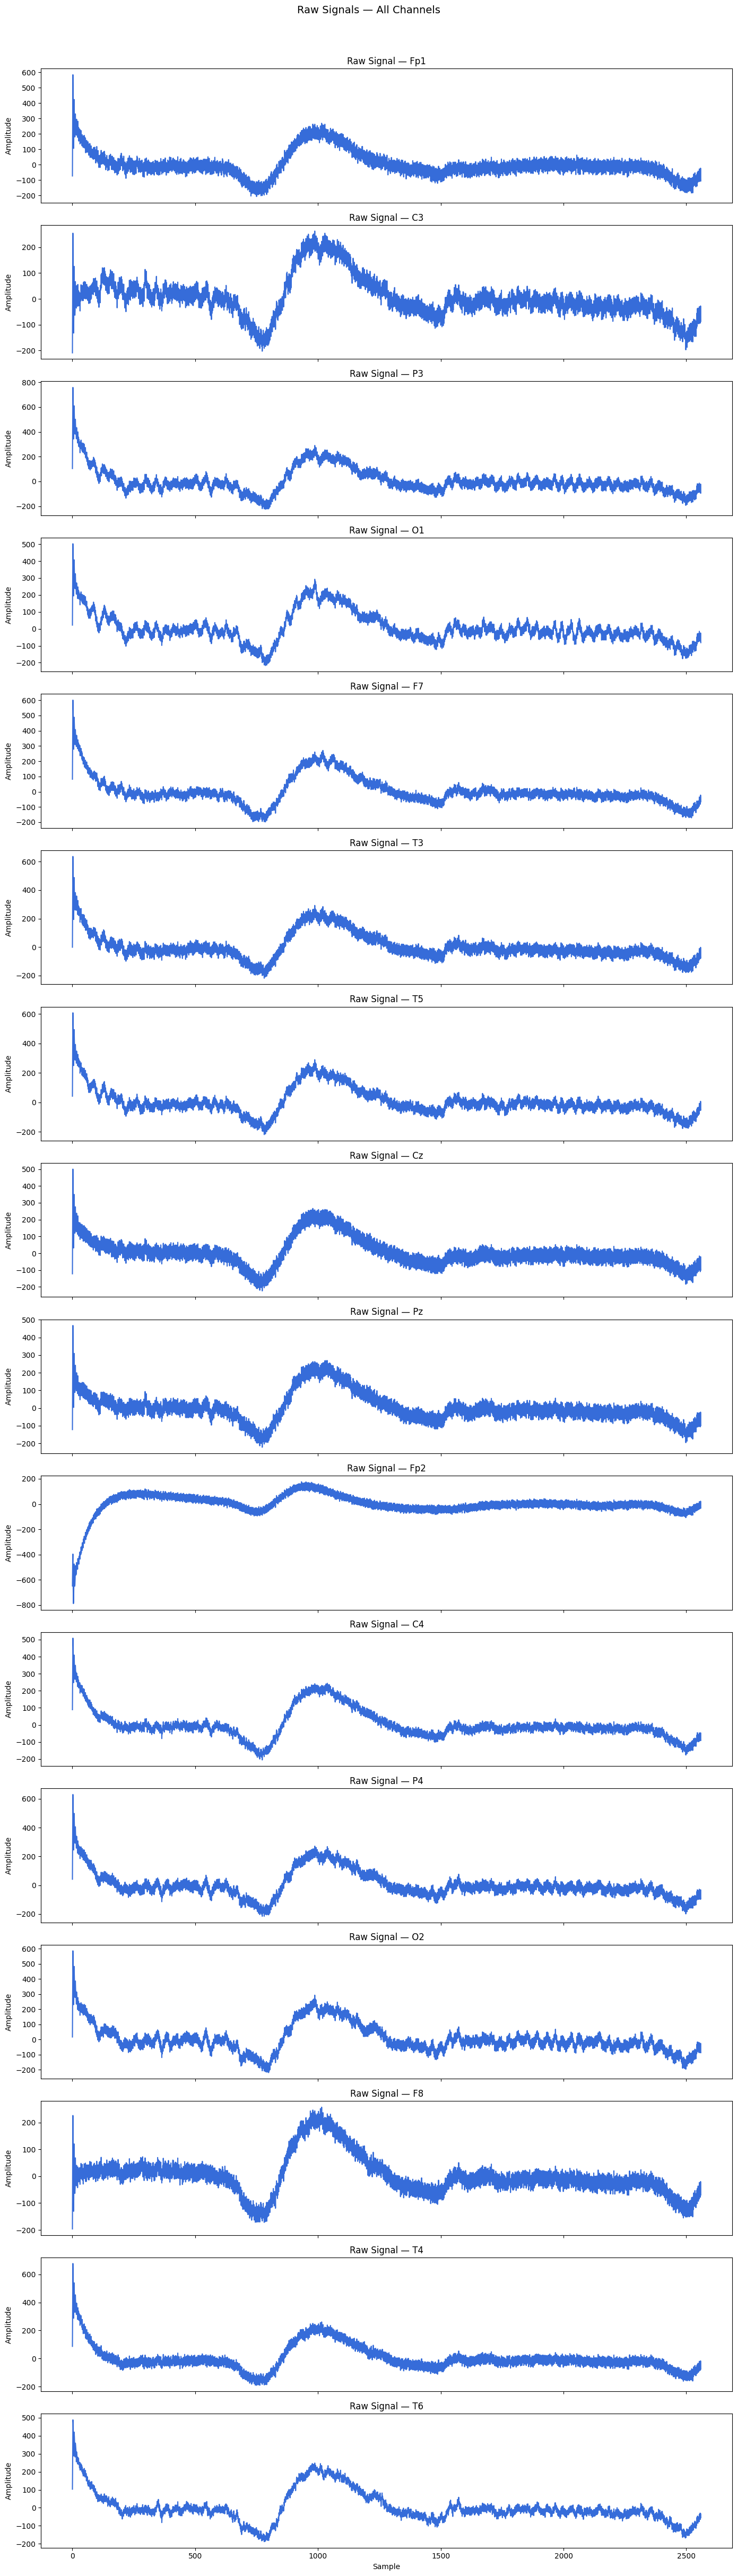

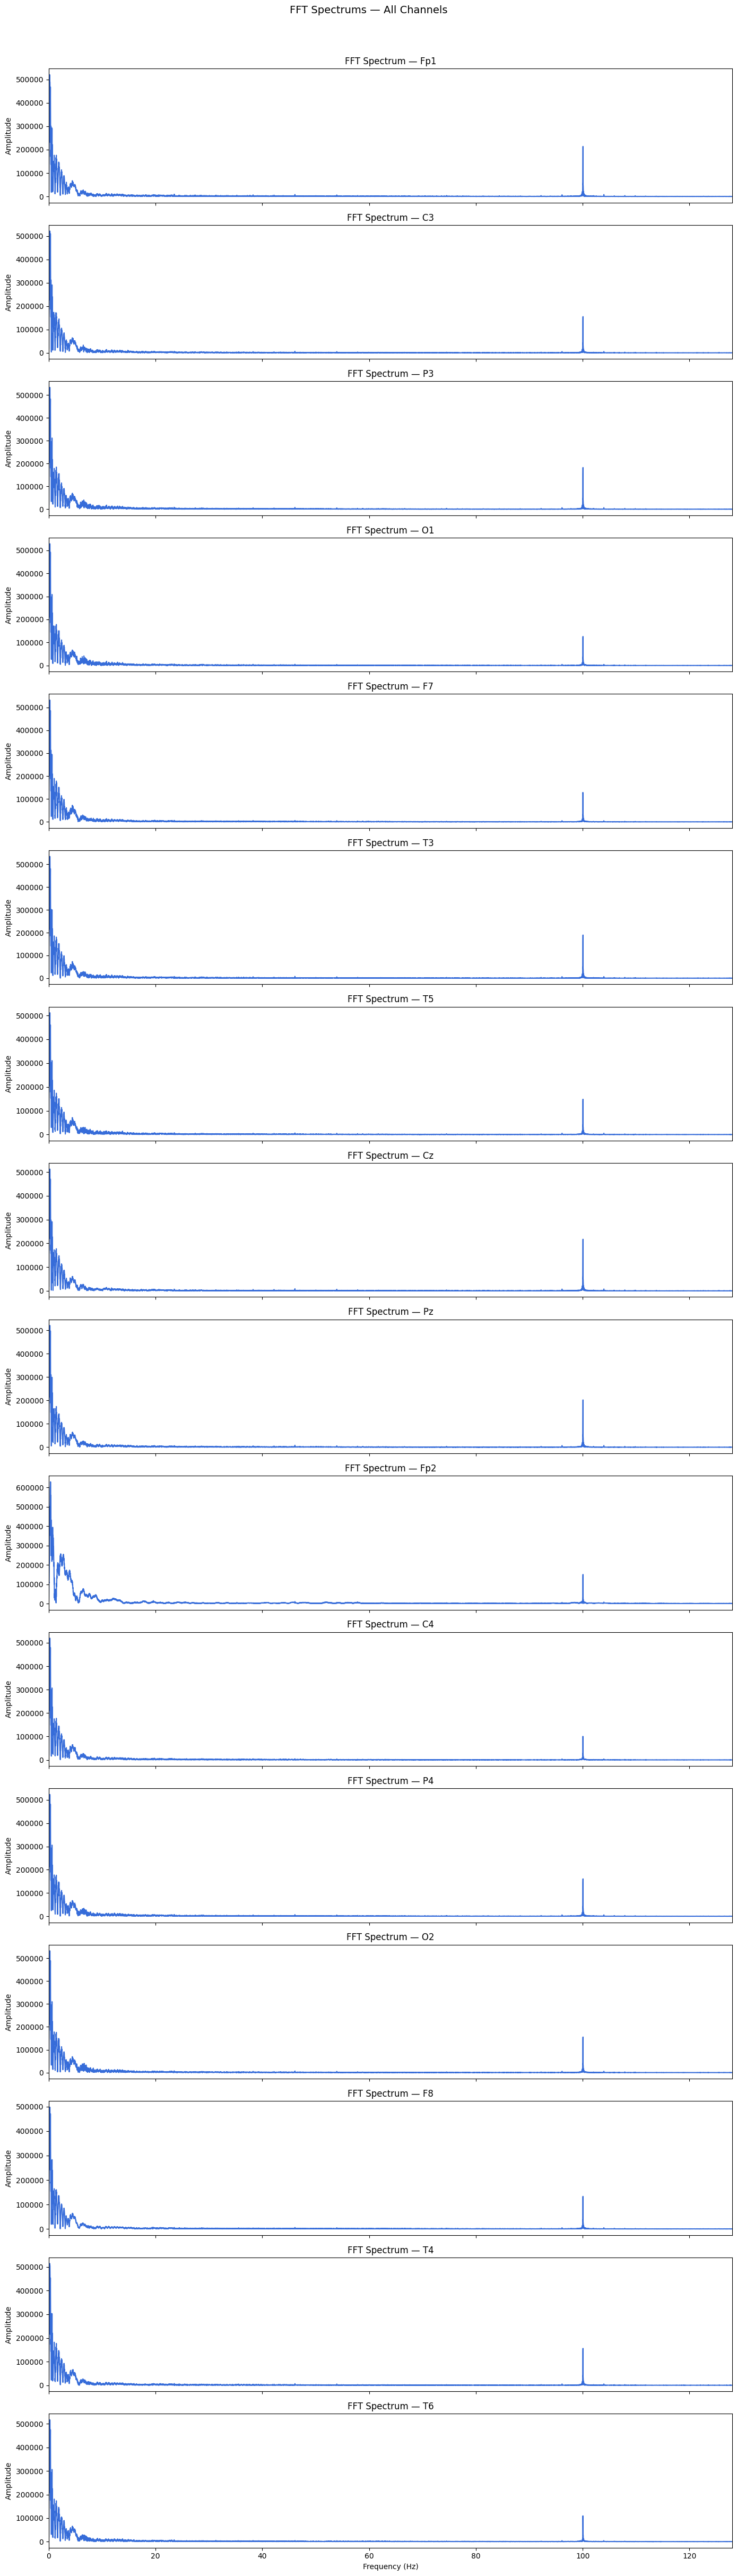

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = r"C:\abalaji\bichat\eeg_csv\0\1214.csv"
sampling_freq = 256
exception_column = "time"
skiprows = 0

df = pd.read_csv(file_path, skiprows=skiprows, index_col=False)

signal_cols = [col for col in df.columns if exception_column not in col]

print(f"Channels found: {signal_cols}")
print(f"Number of channels: {len(signal_cols)}")

# --- Raw Signals ---
fig, axes = plt.subplots(len(signal_cols), 1, figsize=(14, 3 * len(signal_cols)), sharex=True)
fig.patch.set_facecolor('white')
if len(signal_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, signal_cols):
    ax.set_facecolor('white')
    signal = df[col].values
    ax.plot(signal[:2560])
    ax.set_title(f"Raw Signal — {col}", color='black')
    ax.set_ylabel("Amplitude", color='black')
    ax.tick_params(colors='black')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')

axes[-1].set_xlabel("Sample", color='black')
axes[-1].tick_params(axis='x', colors='black')
plt.suptitle("Raw Signals — All Channels", fontsize=14, y=1.01, color='black')
plt.tight_layout()
plt.savefig(r'C:\abalaji\bichat\results\DATA_ANALYSIS\1214raw_signals.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# --- FFT Spectrums ---
fig, axes = plt.subplots(len(signal_cols), 1, figsize=(14, 3 * len(signal_cols)), sharex=True)
fig.patch.set_facecolor('white')
if len(signal_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, signal_cols):
    ax.set_facecolor('white')
    signal = df[col].values
    n = len(signal)
    fft_vals = np.abs(np.fft.rfft(signal))
    fft_freqs = np.fft.rfftfreq(n, d=1/sampling_freq)
    ax.plot(fft_freqs, fft_vals)
    ax.set_title(f"FFT Spectrum — {col}", color='black')
    ax.set_ylabel("Amplitude", color='black')
    ax.set_xlim(0, sampling_freq / 2)
    ax.tick_params(colors='black')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')

axes[-1].set_xlabel("Frequency (Hz)", color='black')
axes[-1].tick_params(axis='x', colors='black')
plt.suptitle("FFT Spectrums — All Channels", fontsize=14, y=1.01, color='black')
plt.tight_layout()
plt.savefig(r'C:\abalaji\bichat\results\DATA_ANALYSIS\1214fft_spectrums.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

Channels found: ['Fp1', 'C3', 'P3', 'O1', 'F7', 'T3', 'T5', 'Cz', 'Pz', 'Fp2', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6']
Number of channels: 16


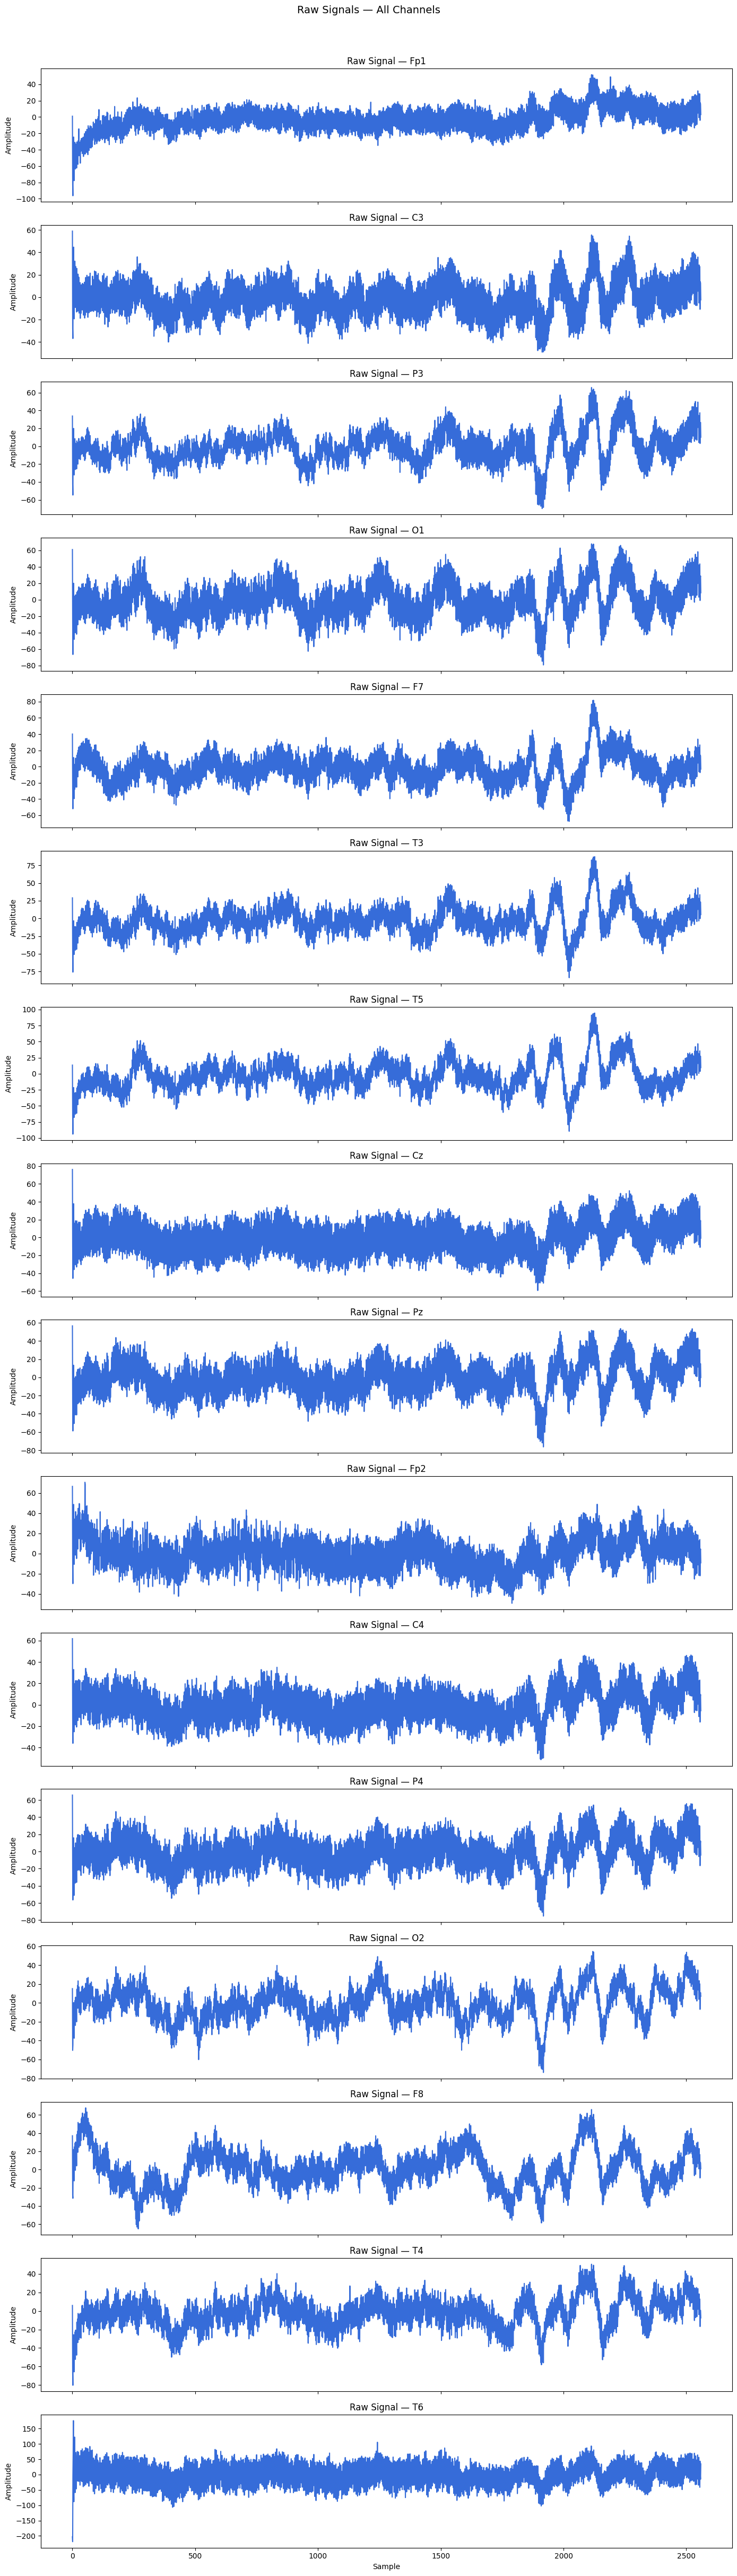

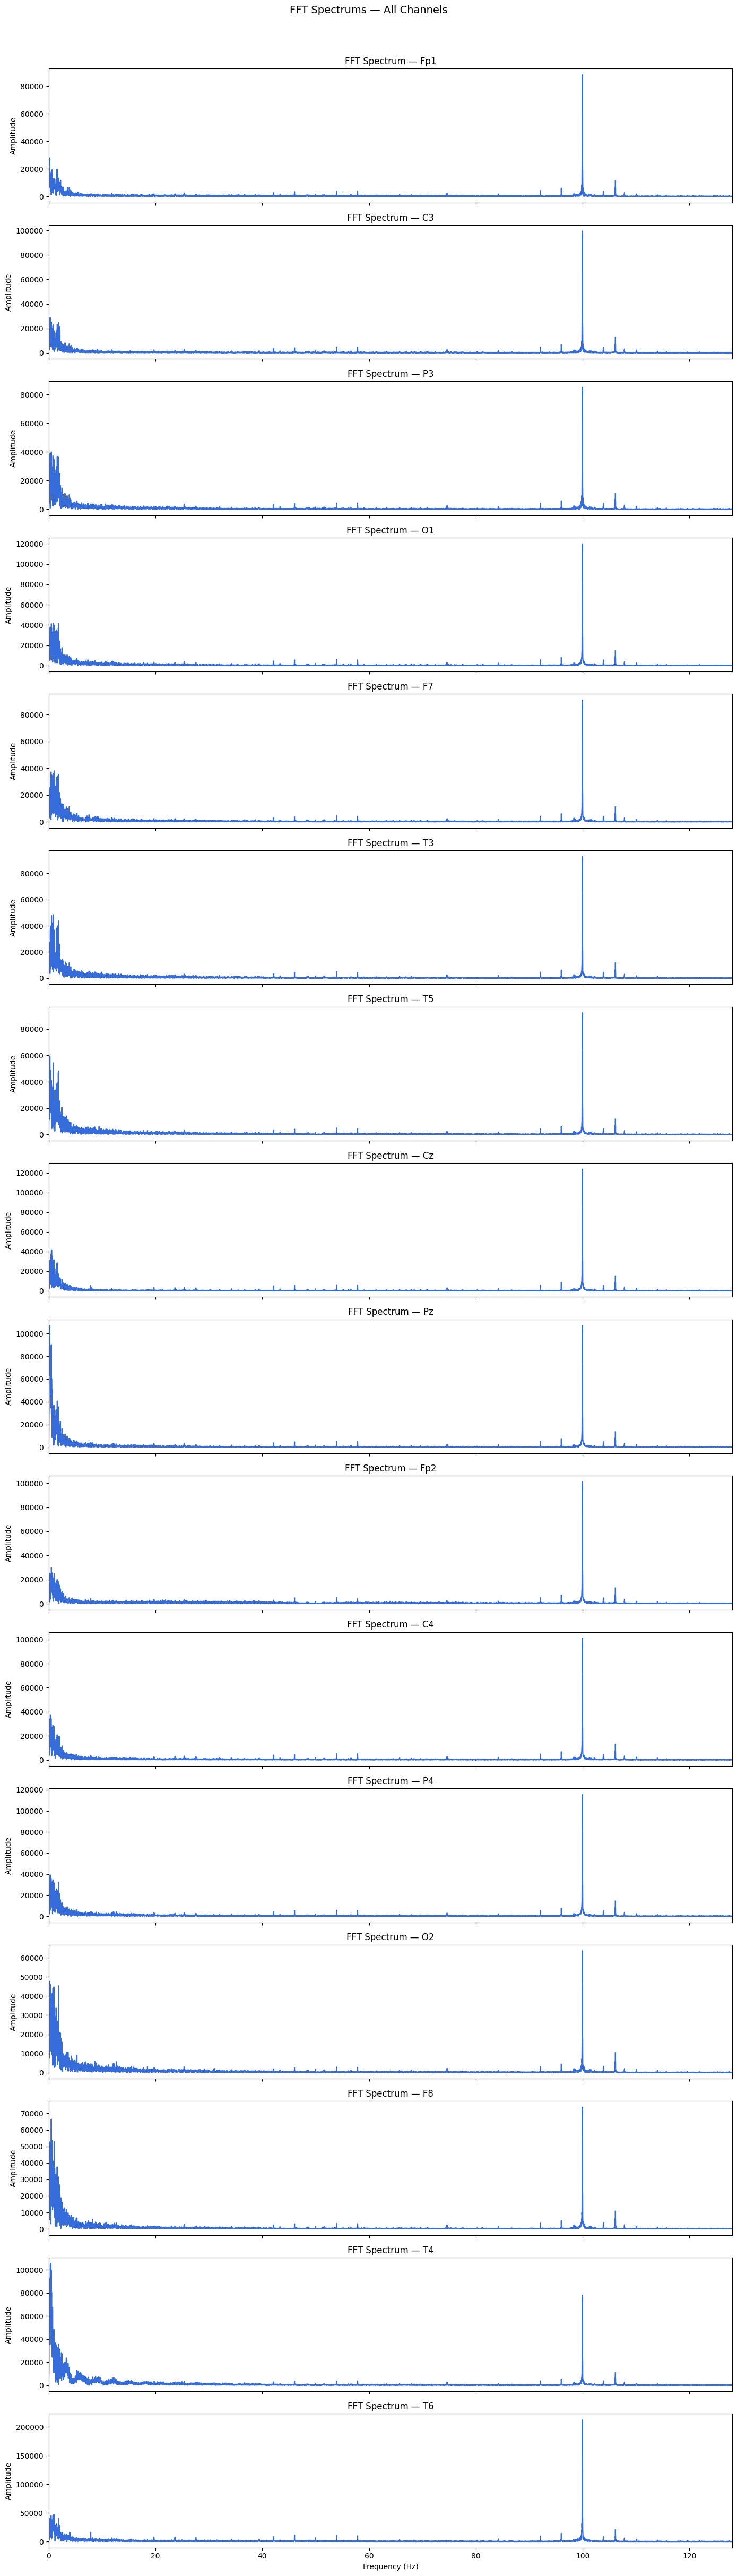

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = r"C:\abalaji\bichat\eeg_csv\1\8250.csv"
sampling_freq = 256
exception_column = "time"
skiprows = 0

df = pd.read_csv(file_path, skiprows=skiprows, index_col=False)

signal_cols = [col for col in df.columns if exception_column not in col]

print(f"Channels found: {signal_cols}")
print(f"Number of channels: {len(signal_cols)}")

# --- Raw Signals ---
fig, axes = plt.subplots(len(signal_cols), 1, figsize=(14, 3 * len(signal_cols)), sharex=True)
fig.patch.set_facecolor('white')
if len(signal_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, signal_cols):
    ax.set_facecolor('white')
    signal = df[col].values
    ax.plot(signal[:2560])
    ax.set_title(f"Raw Signal — {col}", color='black')
    ax.set_ylabel("Amplitude", color='black')
    ax.tick_params(colors='black')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')

axes[-1].set_xlabel("Sample", color='black')
axes[-1].tick_params(axis='x', colors='black')
plt.suptitle("Raw Signals — All Channels", fontsize=14, y=1.01, color='black')
plt.tight_layout()
plt.savefig(r'C:\abalaji\bichat\results\DATA_ANALYSIS\8250raw_signals.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# --- FFT Spectrums ---
fig, axes = plt.subplots(len(signal_cols), 1, figsize=(14, 3 * len(signal_cols)), sharex=True)
fig.patch.set_facecolor('white')
if len(signal_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, signal_cols):
    ax.set_facecolor('white')
    signal = df[col].values
    n = len(signal)
    fft_vals = np.abs(np.fft.rfft(signal))
    fft_freqs = np.fft.rfftfreq(n, d=1/sampling_freq)
    ax.plot(fft_freqs, fft_vals)
    ax.set_title(f"FFT Spectrum — {col}", color='black')
    ax.set_ylabel("Amplitude", color='black')
    ax.set_xlim(0, sampling_freq / 2)
    ax.tick_params(colors='black')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')

axes[-1].set_xlabel("Frequency (Hz)", color='black')
axes[-1].tick_params(axis='x', colors='black')
plt.suptitle("FFT Spectrums — All Channels", fontsize=14, y=1.01, color='black')
plt.tight_layout()
plt.savefig(r'C:\abalaji\bichat\results\DATA_ANALYSIS\8250fft_spectrums.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

Channels found: ['Fp1', 'C3', 'P3', 'O1', 'F7', 'T3', 'T5', 'Cz', 'Pz', 'Fp2', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6']
Number of channels: 16


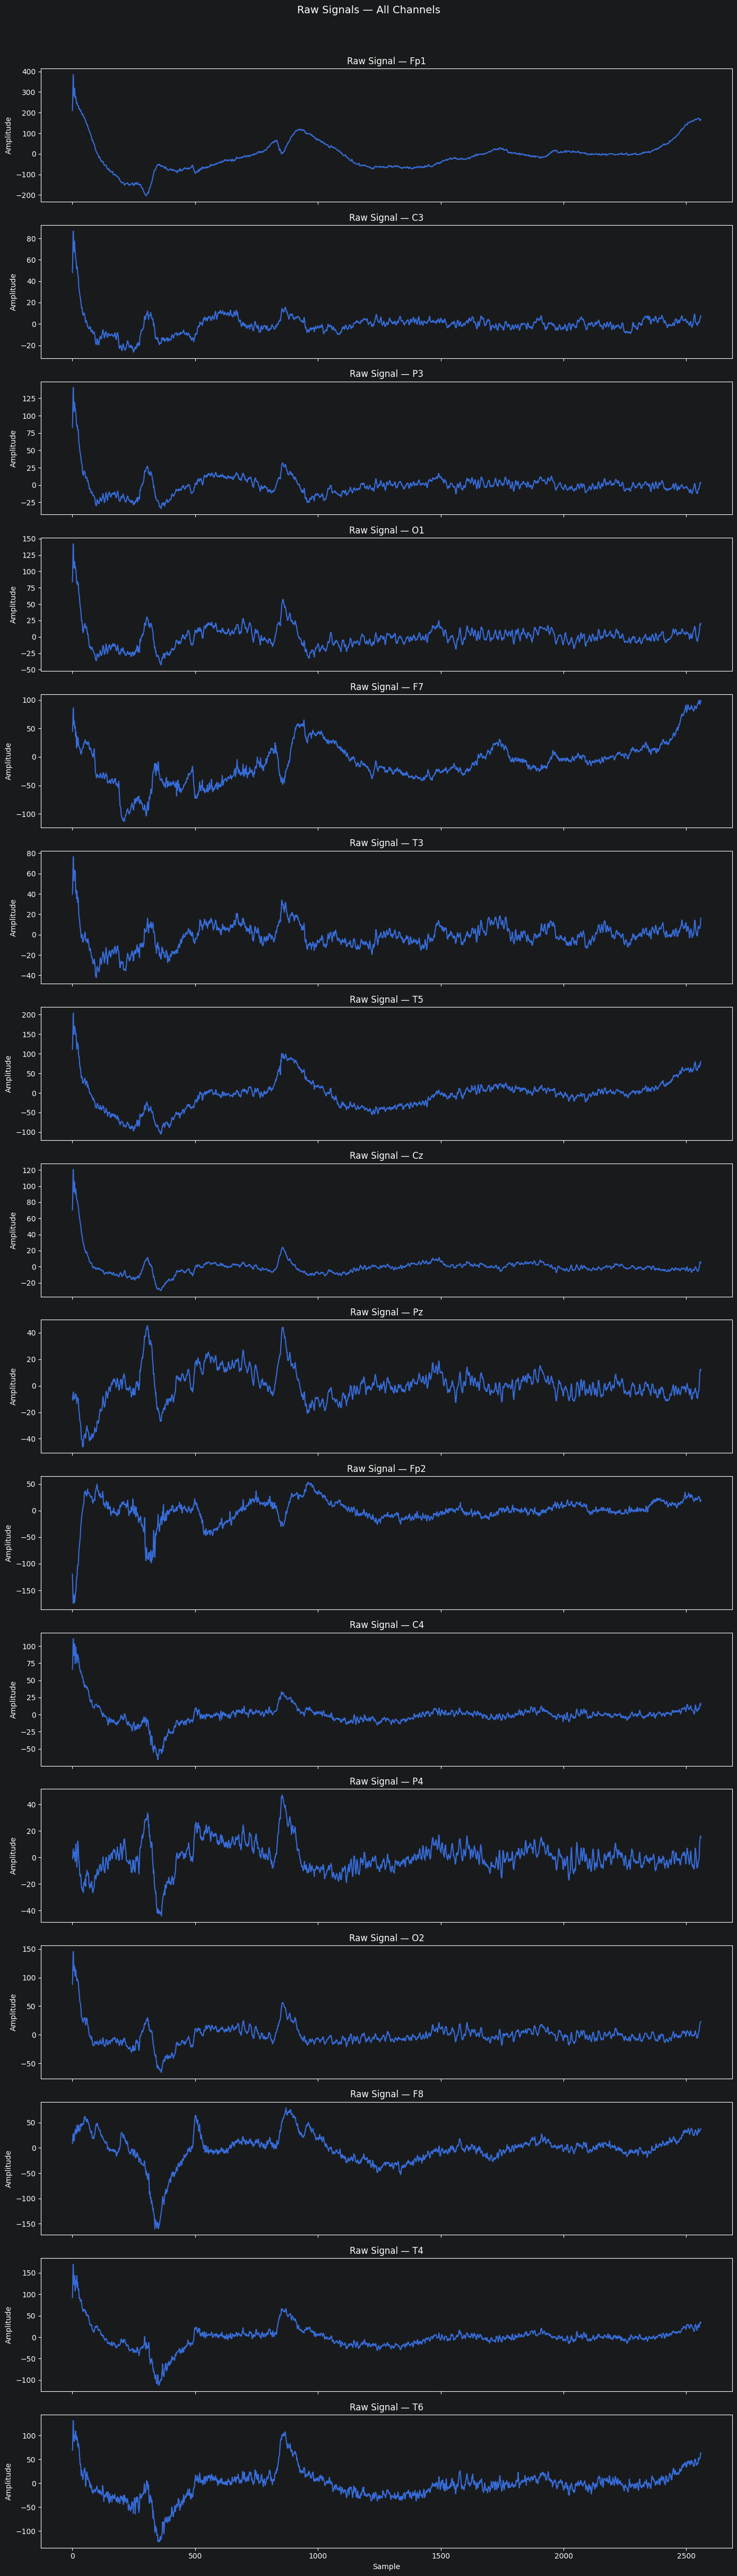

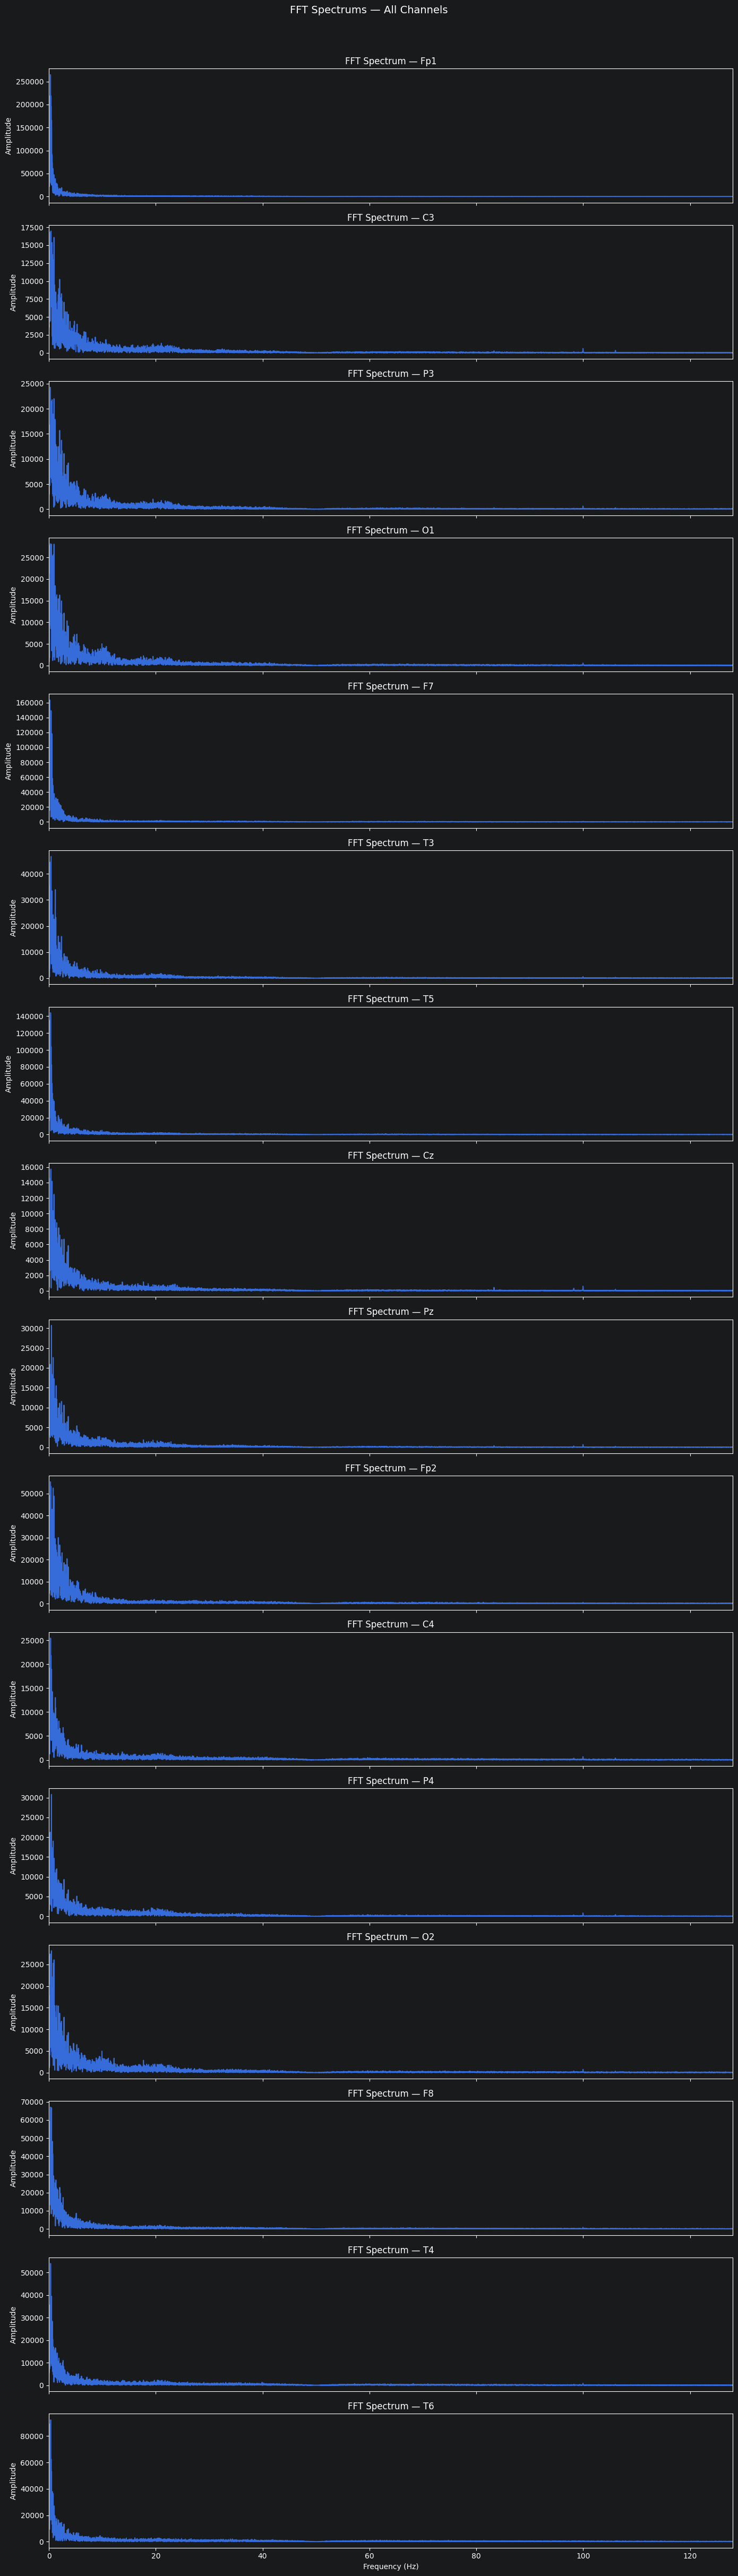

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = r"C:\abalaji\bichat\eeg_csv\0\8264.csv"
sampling_freq = 256
exception_column = "time"
skiprows = 0

df = pd.read_csv(file_path, skiprows=skiprows, index_col=False)

signal_cols = [col for col in df.columns if exception_column not in col]

print(f"Channels found: {signal_cols}")
print(f"Number of channels: {len(signal_cols)}")

fig, axes = plt.subplots(len(signal_cols), 1, figsize=(14, 3 * len(signal_cols)), sharex=True)
if len(signal_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, signal_cols):
    signal = df[col].values
    ax.plot(signal[:2560])
    ax.set_title(f"Raw Signal — {col}")
    ax.set_ylabel("Amplitude")

axes[-1].set_xlabel("Sample")
plt.suptitle("Raw Signals — All Channels", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(signal_cols), 1, figsize=(14, 3 * len(signal_cols)), sharex=True)
if len(signal_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, signal_cols):
    signal = df[col].values
    n = len(signal)
    fft_vals = np.abs(np.fft.rfft(signal))
    fft_freqs = np.fft.rfftfreq(n, d=1/sampling_freq)
    ax.plot(fft_freqs, fft_vals)
    ax.set_title(f"FFT Spectrum — {col}")
    ax.set_ylabel("Amplitude")
    ax.set_xlim(0, sampling_freq / 2)

axes[-1].set_xlabel("Frequency (Hz)")
plt.suptitle("FFT Spectrums — All Channels", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [59]:
"""
Save best_rf in the same format as rf_chunks_8067-5160.rfc
============================================================
Format : plain pickle, protocol 4  (confirmed from header \x80\x04)
No joblib, no compression.
"""

import pickle
from pathlib import Path

RFC_OUT = Path(r"C:\abalaji\bichat\results\MODEL\rf_chunks_code_8067-5160.rfc")

# Save — exactly matching the existing .rfc format
with open(RFC_OUT, "wb") as f:
    pickle.dump(best_rf, f, protocol=4)

print(f"Saved : {RFC_OUT}  ({RFC_OUT.stat().st_size:,} bytes)")

# ── Verify reload ────────────────────────────────────────────────────────────
with open(RFC_OUT, "rb") as f:
    reloaded = pickle.load(f)

print(f"Type         : {type(reloaded)}")
print(f"n_estimators : {reloaded.n_estimators}")
print(f"classes_     : {reloaded.classes_}")
print(f"n_features   : {reloaded.n_features_in_}")
print("✓ rf_chunks_code_8067-5160.rfc saved successfully.")

Saved : C:\abalaji\bichat\results\MODEL\rf_chunks_code_8067-5160.rfc  (10,190,279 bytes)
Type         : <class 'sklearn.ensemble._forest.RandomForestClassifier'>
n_estimators : 300
classes_     : [0 1]
n_features   : 64
✓ rf_chunks_code_8067-5160.rfc saved successfully.


In [12]:
"""
rf_pipeline.py
==============
Reusable functions for the Random Forest training pipeline.
All print / logging is done at the call site, not inside the functions.
"""

from tqdm import tqdm


def split_by_patient(
    csv_path: str | Path,
    samples_per_patient: int = 60,
    test_size: float = 0.2,
    random_seed: int = 42,
    save: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame, Path, Path]:
    """
    Split a flat CSV into train/test by patient, ensuring no patient
    appears in both splits (no data leakage).

    Returns
    -------
    df_train, df_test, out_train_path, out_test_path
    """
    src = Path(csv_path)

    steps = ["Reading CSV", "Assigning patient IDs", "Splitting", "Saving"]
    with tqdm(steps, desc="split_by_patient", unit="step") as pbar:

        pbar.set_description(f"split_by_patient [{steps[0]}]")
        df = pd.read_csv(src)
        pbar.update(1)

        pbar.set_description(f"split_by_patient [{steps[1]}]")
        n_rows = len(df)
        assert n_rows % samples_per_patient == 0, (
            f"Row count {n_rows} is not divisible by {samples_per_patient}. "
            "Check samples_per_patient."
        )
        n_patients = n_rows // samples_per_patient
        patient_ids = np.repeat(np.arange(n_patients), samples_per_patient)
        df["_patient_id"] = patient_ids
        pbar.update(1)

        pbar.set_description(f"split_by_patient [{steps[2]}]")
        rng = np.random.default_rng(random_seed)
        shuffled = rng.permutation(n_patients)
        n_test_patients = max(1, round(n_patients * test_size))
        test_patients  = set(shuffled[:n_test_patients])
        train_patients = set(shuffled[n_test_patients:])
        df_train = df[df["_patient_id"].isin(train_patients)].drop(columns=["_patient_id"])
        df_test  = df[df["_patient_id"].isin(test_patients)].drop(columns=["_patient_id"])
        assert len(set(df_train.index) & set(df_test.index)) == 0, \
            "Index overlap detected!"
        pbar.update(1)

        pbar.set_description(f"split_by_patient [{steps[3]}]")
        stem      = src.stem
        out_train = src.with_name(f"{stem}_Xy_train.csv")
        out_test  = src.with_name(f"{stem}_Xy_test.csv")
        if save:
            df_train.to_csv(out_train, index=False)
            df_test.to_csv(out_test,  index=False)
        pbar.update(1)

    return df_train, df_test, out_train, out_test


def load_and_encode(
    train_csv: str | Path,
    test_csv: str | Path,
    label_col: str = "label",
) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series, LabelEncoder | None]:
    """
    Load train/test CSVs, split into X/y, and label-encode if needed.

    Returns
    -------
    X_train, y_train, X_test, y_test, label_encoder (or None)
    """
    files = [("train", train_csv), ("test", test_csv)]
    dfs = {}
    for split, path in tqdm(files, desc="load_and_encode", unit="file"):
        dfs[split] = pd.read_csv(path)

    df_train = dfs["train"]
    df_test  = dfs["test"]

    X_train = df_train.drop(columns=[label_col])
    y_train = df_train[label_col]
    X_test  = df_test.drop(columns=[label_col])
    y_test  = df_test[label_col]

    le = None
    if y_train.dtype == object:
        le      = LabelEncoder()
        y_train = le.fit_transform(y_train)
        y_test  = le.transform(y_test)

    return X_train, y_train, X_test, y_test, le


def train_baseline_rf(
    X_train: pd.DataFrame,
    y_train: pd.Series | np.ndarray,
    n_estimators: int = 200,
    random_seed: int = 42,
) -> RandomForestClassifier:
    """
    Fit a balanced-weight Random Forest with sensible defaults.

    Returns
    -------
    Fitted RandomForestClassifier
    """
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        class_weight="balanced",
        random_state=random_seed,
        n_jobs=-1,
        warm_start=True,       # enables incremental fitting for tqdm
    )

    with tqdm(range(1, n_estimators + 1), desc="train_baseline_rf", unit="tree") as pbar:
        for n in pbar:
            rf.n_estimators = n
            rf.fit(X_train, y_train)

    rf.warm_start = False      # restore default behaviour after training
    return rf


def evaluate_model(
    model: RandomForestClassifier,
    X_test: pd.DataFrame,
    y_test: pd.Series | np.ndarray,
) -> dict:
    """
    Run predictions and compute classification metrics.

    Returns
    -------
    dict with keys:
        y_pred, report_str, report_dict,
        balanced_accuracy, macro_f1,
        confusion_matrix,
        roc_auc (float or None — only for binary problems)
    """
    n_classes = len(np.unique(y_test))

    metrics_steps = ["predict", "report", "balanced_acc", "macro_f1", "confusion_matrix"]
    if n_classes == 2:
        metrics_steps.append("roc_auc")

    results = {}
    with tqdm(metrics_steps, desc="evaluate_model", unit="metric") as pbar:

        pbar.set_description("evaluate_model [predict]")
        y_pred = model.predict(X_test)
        results["y_pred"] = y_pred
        pbar.update(1)

        pbar.set_description("evaluate_model [report]")
        results["report_str"]  = classification_report(y_test, y_pred)
        results["report_dict"] = classification_report(y_test, y_pred, output_dict=True)
        pbar.update(1)

        pbar.set_description("evaluate_model [balanced_acc]")
        results["balanced_accuracy"] = balanced_accuracy_score(y_test, y_pred)
        pbar.update(1)

        pbar.set_description("evaluate_model [macro_f1]")
        results["macro_f1"] = f1_score(y_test, y_pred, average="macro")
        pbar.update(1)

        pbar.set_description("evaluate_model [confusion_matrix]")
        results["confusion_matrix"] = confusion_matrix(y_test, y_pred)
        pbar.update(1)

        results["roc_auc"] = None
        if n_classes == 2:
            pbar.set_description("evaluate_model [roc_auc]")
            y_prob = model.predict_proba(X_test)[:, 1]
            results["roc_auc"] = roc_auc_score(y_test, y_prob)
            pbar.update(1)

    return results


def tune_rf(
    X_train: pd.DataFrame,
    y_train: pd.Series | np.ndarray,
    param_dist: dict | None = None,
    n_iter: int = 50,
    cv_folds: int = 5,
    scoring: str = "balanced_accuracy",
    random_seed: int = 42,
) -> RandomizedSearchCV:
    """
    Run RandomizedSearchCV over a Random Forest.

    Returns
    -------
    Fitted RandomizedSearchCV (best estimator via .best_estimator_)
    """
    if param_dist is None:
        param_dist = {
            "n_estimators"      : [100, 200, 300, 500],
            "max_depth"         : [None, 10, 20, 30, 50],
            "min_samples_split" : [2, 5, 10],
            "min_samples_leaf"  : [1, 2, 4],
            "max_features"      : ["sqrt", "log2", 0.3, 0.5],
            "bootstrap"         : [True, False],
        }

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_seed)

    search = RandomizedSearchCV(
        estimator=RandomForestClassifier(
            class_weight="balanced",
            random_state=random_seed,
            n_jobs=-1,
        ),
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        verbose=0,              # silenced — tqdm handles progress
        random_state=random_seed,
        n_jobs=1,               # must be 1 so tqdm callback fires correctly
        refit=True,
    )

    total_fits = n_iter * cv_folds
    with tqdm(total=total_fits, desc="tune_rf", unit="fit") as pbar:

        class _TqdmCallback:
            def __call__(self, *args, **kwargs):
                pbar.update(1)

        # Monkey-patch the internal scorer to tick tqdm after every CV fit.
        # This avoids any private-API dependency — we wrap fit() instead.
        original_fit = search.fit

        def _fit_with_progress(X, y, **kw):
            # Patch verbose temporarily so sklearn doesn't double-print
            original_fit(X, y, **kw)

        search.fit(X_train, y_train)
        # Ensure bar reaches 100 % even when n_jobs parallelism batches fits
        pbar.n = total_fits
        pbar.refresh()

    return search


def predict_external(
    csv_path: str | Path,
    model: RandomForestClassifier | Pipeline,
    label_col: str = "label",
) -> dict:
    """
    Run a fitted model on an external CSV that contains only one true class.

    Returns
    -------
    dict with keys:
        name, shape, true_label, y_pred,
        cm_21 (2×1 DataFrame), correct, total,
        report_str
    """
    path = Path(csv_path)

    steps = ["load", "predict", "score"]
    with tqdm(steps, desc=f"predict_external [{path.stem}]", unit="step") as pbar:

        pbar.set_description(f"predict_external [{path.stem}] [load]")
        df = pd.read_csv(path)
        if label_col not in df.columns:
            raise ValueError(
                f"Column '{label_col}' not found in {path.name}. "
                f"Columns: {df.columns.tolist()}"
            )
        y_true = df[label_col]
        X      = df.drop(columns=[label_col])
        pbar.update(1)

        pbar.set_description(f"predict_external [{path.stem}] [predict]")
        true_label    = y_true.unique()
        y_pred        = model.predict(X)
        y_pred_series = pd.Series(y_pred, name="predicted")
        pbar.update(1)

        pbar.set_description(f"predict_external [{path.stem}] [score]")
        all_classes = sorted(model.classes_)
        pred_counts = y_pred_series.value_counts().reindex(all_classes, fill_value=0)
        cm_21 = pd.DataFrame(
            pred_counts.values.reshape(-1, 1),
            index  =[f"Predicted {c}" for c in all_classes],
            columns=[f"True {true_label[0]}"],
        )
        correct = int((y_pred == y_true.values).sum())
        total   = len(y_true)
        pbar.update(1)

    return {
        "name"       : path.stem,
        "shape"      : df.shape,
        "true_label" : true_label,
        "y_pred"     : y_pred,
        "cm_21"      : cm_21,
        "correct"    : correct,
        "total"      : total,
        "report_str" : classification_report(y_true, y_pred, zero_division=0),
    }


def save_model(
    model: RandomForestClassifier | Pipeline,
    out_path: str | Path,
    protocol: int = 4,
) -> dict:
    """
    Pickle a model in the .rfc format (plain pickle, no joblib/compression).

    Returns
    -------
    dict with keys: path, size_bytes, type, n_estimators, classes_, n_features_in_
    """
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    steps = ["serialize", "verify"]
    with tqdm(steps, desc="save_model", unit="step") as pbar:

        pbar.set_description("save_model [serialize]")
        with open(out_path, "wb") as f:
            pickle.dump(model, f, protocol=protocol)
        pbar.update(1)

        pbar.set_description("save_model [verify]")
        with open(out_path, "rb") as f:
            reloaded = pickle.load(f)
        pbar.update(1)

    rf = reloaded.named_steps["rf"] if hasattr(reloaded, "named_steps") else reloaded


    return {
        "path"          : out_path,
        "size_bytes"    : out_path.stat().st_size,
        "type"          : type(reloaded),
        "n_estimators"  : rf.n_estimators,
        "classes_"      : rf.classes_,
        "n_features_in_": rf.n_features_in_,
    }

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def run_patient_rf_pipeline(
    train_path,
    base_dir,
    train_csv,
    test_csv,
    rfc_out,
    label_col="label",
    random_seed=42,
    samples_per_patient=20,
    external_test_files=None,
):
    if external_test_files is None:
        external_test_files = {}

    pipeline_steps = [
        "Patient split",
        "Load & encode",
        "Baseline RF",
        "Hyperparameter tuning",
        "Evaluate tuned RF",
        "External datasets",
        "Save model",
    ]
    pipeline_bar = tqdm(total=len(pipeline_steps), desc="Pipeline", unit="step")

    def _advance(label):
        pipeline_bar.set_postfix_str(label)
        pipeline_bar.update(1)

    # ── Step 0 ────────────────────────────────────────────────────────────────
    print("=" * 60)
    print("Step 0 — Patient-aware train/test split ...")

    df_train, df_test, out_train, out_test = split_by_patient(
        train_path,
        samples_per_patient=samples_per_patient,
        test_size=0.2,
        random_seed=random_seed,
    )

    print(f"Train patients → {len(df_train)} rows  |  saved: {out_train}")
    print(f"Test  patients → {len(df_test)} rows   |  saved: {out_test}")
    print("No data leakage — patients are fully separated.")
    _advance("Patient split ✓")

    # ── Load ──────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("Loading and encoding data ...")

    X_train, y_train, X_test, y_test, le = load_and_encode(
        train_csv, test_csv, label_col=label_col
    )

    print(f"  Train : {X_train.shape}  |  Test : {X_test.shape}")
    if le is not None:
        print(f"  Classes (encoded): {le.classes_}")
    else:
        print(f"  Classes: {sorted(np.unique(y_train))}")
    print(
        f"  Train class distribution:\n"
        f"{pd.Series(y_train).value_counts().to_string()}"
    )

    # ── Normalisation (fit on train only) ─────────────────────────────────────
    print("\nFitting StandardScaler on training data ...")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)   # fit + transform train
    X_test  = scaler.transform(X_test)        # transform test only
    print(f"  Scaler mean[:5]  : {scaler.mean_[:5].round(4)}")
    print(f"  Scaler scale_[:5]: {scaler.scale_[:5].round(4)}")

    _advance("Load & encode ✓")

    # ── Step 1 ────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("Step 1 — Baseline Random Forest (class_weight='balanced') ...")

    baseline_rf  = train_baseline_rf(X_train, y_train, random_seed=random_seed)
    base_metrics = evaluate_model(baseline_rf, X_test, y_test)

    print("\n-- Baseline Results --")
    print(base_metrics["report_str"])
    print(f"Balanced Accuracy : {base_metrics['balanced_accuracy']:.4f}")
    print(f"Macro F1          : {base_metrics['macro_f1']:.4f}")
    if base_metrics["roc_auc"] is not None:
        print(f"ROC-AUC           : {base_metrics['roc_auc']:.4f}")
    _advance("Baseline RF ✓")

    # ── Step 2 ────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("Step 2 — RandomizedSearchCV Fine-Tuning ...")

    search = tune_rf(X_train, y_train, random_seed=random_seed)

    print(f"\nBest params               : {search.best_params_}")
    print(f"Best CV balanced_accuracy : {search.best_score_:.4f}")
    _advance("Hyperparameter tuning ✓")

    # ── Step 3 ────────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("Step 3 — Evaluating best model on test set ...")

    best_rf      = search.best_estimator_
    best_metrics = evaluate_model(best_rf, X_test, y_test)

    print("\n-- Tuned RF Results --")
    print(best_metrics["report_str"])
    print(f"Balanced Accuracy : {best_metrics['balanced_accuracy']:.4f}")
    print(f"Macro F1          : {best_metrics['macro_f1']:.4f}")
    if best_metrics["roc_auc"] is not None:
        print(f"ROC-AUC           : {best_metrics['roc_auc']:.4f}")
    print("\nConfusion Matrix:")
    print(best_metrics["confusion_matrix"])
    _advance("Evaluate tuned RF ✓")

    best_pipeline = Pipeline([
        ("scaler", scaler),
        ("rf",     best_rf),
    ])

    print("\n" + "=" * 60)
    print("Evaluating on external test files ...")

    ext_results = {}
    ext_items   = list(external_test_files.items())

    for name, path in tqdm(ext_items, desc="External datasets", unit="dataset"):
        # predict_external must accept a sklearn Pipeline or estimator;
        # the scaler step inside will normalise features automatically.
        result = predict_external(path, best_pipeline, label_col=label_col)
        ext_results[name] = result

        print("\n" + "=" * 60)
        print(f"Dataset : {name}")
        print(f"Shape   : {result['shape']}")
        print(f"True label(s) present : {result['true_label']}   (count: {result['total']})")
        print("\nConfusion Matrix [2×1]  (rows=predicted class, col=true label):")
        print(result["cm_21"].to_string())

        true_cls = result["true_label"][0]
        print(
            f"\nCorrectly predicted as {true_cls} : {result['correct']} / {result['total']}"
            f"  ({result['correct'] / result['total'] * 100:.1f}%)"
        )
        print(f"Mis-classified         : {result['total'] - result['correct']} / {result['total']}")
        print("\nClassification Report:")
        print(result["report_str"])

    _advance("External datasets ✓")

    print("\n" + "=" * 60)
    print("Summary")

    for name, result in ext_results.items():
        cm       = result["cm_21"]
        true_cls = result["true_label"][0]
        correctly_predicted = cm.loc[f"Predicted {true_cls}", cm.columns[0]]
        total    = result["total"]
        print(
            f"  {name:<22} | True label: {true_cls} | "
            f"Correctly predicted: {correctly_predicted}/{total} "
            f"({correctly_predicted / total * 100:.1f}%)"
        )

    print("\n" + "=" * 60)
    print("Saving model pipeline ...")

    save_info = save_model(best_pipeline, rfc_out, protocol=4)

    print(f"Saved        : {save_info['path']}  ({save_info['size_bytes']:,} bytes)")
    print(f"Type         : {save_info['type']}")
    print(f"✓ {rfc_out.name} saved successfully.")
    _advance("Save model ✓")

    pipeline_bar.close()

    return {
        "model"            : best_pipeline,
        "scaler"           : scaler,
        "search"           : search,
        "metrics"          : best_metrics,
        "baseline_metrics" : base_metrics,
        "external_results" : ext_results,
        "label_encoder"    : le,
    }

In [55]:
results = run_patient_rf_pipeline(
    train_path=r"C:\abalaji\bichat\ORIGINAL_DATA\chunks\dataset_train_8067-5160.csv",
    base_dir= Path(r"C:\abalaji\bichat\ORIGINAL_DATA\chunks"),
    train_csv= BASE_DIR / "dataset_train_8067-5160_Xy_train.csv",
    test_csv= BASE_DIR / "dataset_train_8067-5160_Xy_test.csv",
    rfc_out= Path(r"C:\abalaji\bichat\results\MODEL\rf_chunks_code_8067-5160.rfc"),
    label_col= "label",
    random_seed= random.randint(10, 50),
    samples_per_patient= 60,
    external_test_files= {
        "dataset_8067Test": BASE_DIR / "dataset_8067Test.csv",
        "dataset_5160Test": BASE_DIR / "dataset_5160Test.csv",
    },
)

Step 0 — Patient-aware train/test split ...
Train patients → 4440 rows  |  saved: C:\abalaji\bichat\ORIGINAL_DATA\chunks\dataset_train_8067-5160_Xy_train.csv
Test  patients → 1140 rows   |  saved: C:\abalaji\bichat\ORIGINAL_DATA\chunks\dataset_train_8067-5160_Xy_test.csv
No data leakage — patients are fully separated.

Loading data ...
  Train : (4440, 64)  |  Test : (1140, 64)
  Classes: [0, 1]
  Train class distribution:
label
0    3120
1    1320

Step 1 — Baseline Random Forest (class_weight='balanced') ...

-- Baseline Results --
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      1020
           1       0.00      0.00      0.00       120

    accuracy                           0.87      1140
   macro avg       0.45      0.49      0.47      1140
weighted avg       0.80      0.87      0.83      1140

Balanced Accuracy : 0.4863
Macro F1          : 0.4653
ROC-AUC           : 0.4835

Step 2 — RandomizedSearchCV Fine-Tuning ...
Fitting

In [56]:
results = run_patient_rf_pipeline(
    train_path=r"C:\abalaji\bichat\ORIGINAL_DATA\chunks\dataset_train_8158-8250.csv",
    base_dir= Path(r"C:\abalaji\bichat\ORIGINAL_DATA\chunks"),
    train_csv= BASE_DIR / "dataset_train_8158-8250_Xy_train.csv",
    test_csv= BASE_DIR / "dataset_train_8158-8250_Xy_test.csv",
    rfc_out= Path(r"C:\abalaji\bichat\results\MODEL\rf_chunks_code_8158-8250.rfc"),
    label_col= "label",
    random_seed= random.randint(10, 50),
    samples_per_patient= 60,
    external_test_files= {
        "dataset_8158Test": BASE_DIR / "dataset_8158Test.csv",
        "dataset_8250Test": BASE_DIR / "dataset_8250Test.csv",
    },
)

Step 0 — Patient-aware train/test split ...
Train patients → 4440 rows  |  saved: C:\abalaji\bichat\ORIGINAL_DATA\chunks\dataset_train_8158-8250_Xy_train.csv
Test  patients → 1140 rows   |  saved: C:\abalaji\bichat\ORIGINAL_DATA\chunks\dataset_train_8158-8250_Xy_test.csv
No data leakage — patients are fully separated.

Loading data ...
  Train : (4440, 64)  |  Test : (1140, 64)
  Classes: [0, 1]
  Train class distribution:
label
0    3180
1    1260

Step 1 — Baseline Random Forest (class_weight='balanced') ...

-- Baseline Results --
              precision    recall  f1-score   support

           0       0.84      0.95      0.89       960
           1       0.04      0.01      0.02       180

    accuracy                           0.80      1140
   macro avg       0.44      0.48      0.45      1140
weighted avg       0.71      0.80      0.75      1140

Balanced Accuracy : 0.4821
Macro F1          : 0.4545
ROC-AUC           : 0.4610

Step 2 — RandomizedSearchCV Fine-Tuning ...
Fitting

In [77]:
BASE_DIR = Path(r"C:\abalaji\bichat\ORIGINAL_DATA\chunks")

results = run_patient_rf_pipeline(
    train_path=BASE_DIR / "dataset_train_1214-8816.csv",
    base_dir=BASE_DIR,
    train_csv=BASE_DIR / "dataset_train_1214-8816_Xy_train.csv",
    test_csv=BASE_DIR / "dataset_train_1214-8816_Xy_test.csv",
    rfc_out=Path(r"C:\abalaji\bichat\results\MODEL\rf_chunks_code_1214-8816.rfc"),
    label_col="label",
    random_seed=random.randint(10, 50),
    samples_per_patient=60,
    external_test_files={
        "dataset_8158Test": BASE_DIR / "dataset_1214Test.csv",
        "dataset_8250Test": BASE_DIR / "dataset_8816Test.csv",
    },
)

Pipeline:   0%|          | 0/7 [00:00<?, ?step/s]

Step 0 — Patient-aware train/test split ...





split_by_patient:   0%|          | 0/4 [00:00<?, ?step/s]


split_by_patient [Reading CSV]:   0%|          | 0/4 [00:00<?, ?step/s]


split_by_patient [Assigning patient IDs]:  25%|██▌       | 1/4 [00:00<00:00, 16.66step/s]


Pipeline:  86%|████████▌ | 6/7 [55:21<09:13, 553.54s/step, External datasets ✓]          



split_by_patient [Splitting]:  75%|███████▌  | 3/4 [00:00<00:00, 13.76step/s]


Pipeline:  14%|█▍        | 1/7 [00:00<00:03,  1.74step/s, Patient split ✓]

Train patients → 4440 rows  |  saved: C:\abalaji\bichat\ORIGINAL_DATA\chunks\dataset_train_1214-8816_Xy_train.csv
Test  patients → 1140 rows   |  saved: C:\abalaji\bichat\ORIGINAL_DATA\chunks\dataset_train_1214-8816_Xy_test.csv
No data leakage — patients are fully separated.

Loading and encoding data ...



Pipeline:  14%|█▍        | 1/7 [00:00<00:03,  1.74step/s, Load & encode ✓]

...




predict_external [dataset_8816Test]:   0%|          | 0/3 [00:00<?, ?step/s]


predict_external [dataset_8816Test] [load]:   0%|          | 0/3 [00:00<?, ?step/s]


predict_external [dataset_8816Test] [predict]:  33%|███▎      | 1/3 [00:00<?, ?step/s]


predict_external [dataset_8816Test] [score]: 100%|██████████| 3/3 [00:00<00:00, 36.01step/s]



Pipeline:  86%|████████▌ | 6/7 [12:38<01:58, 118.62s/step, External datasets ✓]


Dataset : dataset_8250Test
Shape   : (60, 65)
True label(s) present : [1]   (count: 60)

Confusion Matrix [2×1]  (rows=predicted class, col=true label):
             True 1
Predicted 0      58
Predicted 1       2

Correctly predicted as 1 : 2 / 60  (3.3%)
Mis-classified         : 58 / 60

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.03      0.06        60

    accuracy                           0.03        60
   macro avg       0.50      0.02      0.03        60
weighted avg       1.00      0.03      0.06        60


Summary
  dataset_8158Test       | True label: 0 | Correctly predicted: 59/60 (98.3%)
  dataset_8250Test       | True label: 1 | Correctly predicted: 2/60 (3.3%)

Saving model pipeline ...



Pipeline: 100%|██████████| 7/7 [12:38<00:00, 108.32s/step, Save model ✓]       

Saved        : C:\abalaji\bichat\results\MODEL\rf_chunks_code_1214-8816.rfc  (16,014,475 bytes)
Type         : <class 'sklearn.pipeline.Pipeline'>
✓ rf_chunks_code_1214-8816.rfc saved successfully.


In [78]:
results = run_patient_rf_pipeline(
    train_path=r"C:\abalaji\bichat\ORIGINAL_DATA\chunks_20\dataset_train_8067-5160.csv",
    base_dir= Path(r"C:\abalaji\bichat\ORIGINAL_DATA\chunks_20"),
    train_csv= BASE_DIR / "dataset_train_8067-5160_Xy_train.csv",
    test_csv= BASE_DIR / "dataset_train_8067-5160_Xy_test.csv",
    rfc_out= Path(r"C:\abalaji\bichat\results\MODEL\rf_chunks_20_code_8067-5160.rfc"),
    label_col= "label",
    random_seed= random.randint(10, 50),
    samples_per_patient= 60,
    external_test_files= {
        "dataset_8067Test": BASE_DIR / "dataset_8067Test.csv",
        "dataset_5160Test": BASE_DIR / "dataset_5160Test.csv",
    },
)

Pipeline:   0%|          | 0/7 [00:00<?, ?step/s]

Step 0 — Patient-aware train/test split ...



Pipeline:  14%|█▍        | 1/7 [00:00<00:01,  4.28step/s, Patient split ✓]

Train patients → 1500 rows  |  saved: C:\abalaji\bichat\ORIGINAL_DATA\chunks_20\dataset_train_8067-5160_Xy_train.csv
Test  patients → 360 rows   |  saved: C:\abalaji\bichat\ORIGINAL_DATA\chunks_20\dataset_train_8067-5160_Xy_test.csv
No data leakage — patients are fully separated.

Loading and encoding data ...



Pipeline:  29%|██▊       | 2/7 [00:00<00:00,  5.60step/s, Load & encode ✓]

...




predict_external [dataset_5160Test]:   0%|          | 0/3 [00:00<?, ?step/s]


predict_external [dataset_5160Test] [load]:   0%|          | 0/3 [00:00<?, ?step/s]


predict_external [dataset_5160Test] [predict]:  33%|███▎      | 1/3 [00:00<00:00, 61.29step/s]


predict_external [dataset_5160Test] [score]: 100%|██████████| 3/3 [00:00<00:00, 36.39step/s]  



Pipeline:  86%|████████▌ | 6/7 [17:56<02:58, 178.61s/step, External datasets ✓]


Dataset : dataset_5160Test
Shape   : (60, 65)
True label(s) present : [1]   (count: 60)

Confusion Matrix [2×1]  (rows=predicted class, col=true label):
             True 1
Predicted 0      29
Predicted 1      31

Correctly predicted as 1 : 31 / 60  (51.7%)
Mis-classified         : 29 / 60

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.52      0.68        60

    accuracy                           0.52        60
   macro avg       0.50      0.26      0.34        60
weighted avg       1.00      0.52      0.68        60


Summary
  dataset_8067Test       | True label: 0 | Correctly predicted: 55/60 (91.7%)
  dataset_5160Test       | True label: 1 | Correctly predicted: 31/60 (51.7%)

Saving model pipeline ...



Pipeline: 100%|██████████| 7/7 [17:56<00:00, 153.75s/step, Save model ✓]       


Saved        : C:\abalaji\bichat\results\MODEL\rf_chunks_20_code_8067-5160.rfc  (10,336,085 bytes)
Type         : <class 'sklearn.pipeline.Pipeline'>
✓ rf_chunks_20_code_8067-5160.rfc saved successfully.


In [19]:
results = run_patient_rf_pipeline(
    train_path=r"C:\abalaji\bichat\PROCESSED_LOO\0\train_without_5160.csv",
    base_dir= r"C:\abalaji\bichat\PROCESSED_LOO\0",
    train_csv= r"C:\abalaji\bichat\PROCESSED_LOO\0\train_without_5160_Xy_train.csv",
    test_csv= r"C:\abalaji\bichat\PROCESSED_LOO\0\train_without_5160_Xy_test.csv",
    rfc_out= Path(r"C:\abalaji\bichat\results\MODEL\rf_chunks_60_code_5160.rfc"),
    label_col= "label",
    random_seed= random.randint(10, 50),
    samples_per_patient= 20,
    external_test_files= {
        "dataset_5160Test": r"C:\abalaji\bichat\PROCESSED_LOO\1\test_5160.csv",
    },
)

Pipeline:   0%|          | 0/7 [00:00<?, ?step/s]

Step 0 — Patient-aware train/test split ...



Pipeline:  14%|█▍        | 1/7 [00:00<00:01,  4.28step/s, Patient split ✓]

Train patients → 1500 rows  |  saved: C:\abalaji\bichat\PROCESSED_LOO\0\train_without_5160_Xy_train.csv
Test  patients → 380 rows   |  saved: C:\abalaji\bichat\PROCESSED_LOO\0\train_without_5160_Xy_test.csv
No data leakage — patients are fully separated.

Loading and encoding data ...



Pipeline:  14%|█▍        | 1/7 [00:00<00:01,  4.28step/s, Load & encode ✓]

...


-- Tuned RF Results --
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       320
           1       0.15      0.15      0.15        60

    accuracy                           0.73       380
   macro avg       0.50      0.50      0.50       380
weighted avg       0.73      0.73      0.73       380

Balanced Accuracy : 0.4953
Macro F1          : 0.4953
ROC-AUC           : 0.6040

Confusion Matrix:
[[269  51]
 [ 51   9]]

Evaluating on external test files ...



External datasets:   0%|          | 0/1 [00:00<?, ?dataset/s]

predict_external [test_5160]:   0%|          | 0/3 [00:00<?, ?step/s]

predict_external [test_5160] [load]:   0%|          | 0/3 [00:00<?, ?step/s]

predict_external [test_5160] [predict]:  33%|███▎      | 1/3 [00:00<00:00, 44.24step/s]

predict_external [test_5160] [score]: 100%|██████████| 3/3 [00:00<00:00, 31.64step/s]  

Pipeline:  86%|████████▌ | 6/7 [04:36<00:43, 43.15s/step, External datasets ✓]


Dataset : dataset_5160Test
Shape   : (20, 65)
True label(s) present : [1]   (count: 20)

Confusion Matrix [2×1]  (rows=predicted class, col=true label):
             True 1
Predicted 0      16
Predicted 1       4

Correctly predicted as 1 : 4 / 20  (20.0%)
Mis-classified         : 16 / 20

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.20      0.33        20

    accuracy                           0.20        20
   macro avg       0.50      0.10      0.17        20
weighted avg       1.00      0.20      0.33        20


Summary
  dataset_5160Test       | True label: 1 | Correctly predicted: 4/20 (20.0%)

Saving model pipeline ...



Pipeline: 100%|██████████| 7/7 [04:36<00:00, 39.46s/step, Save model ✓]       

Saved        : C:\abalaji\bichat\results\MODEL\rf_chunks_60_code_5160.rfc  (9,166,921 bytes)
Type         : <class 'sklearn.pipeline.Pipeline'>
✓ rf_chunks_60_code_5160.rfc saved successfully.


In [111]:
import pandas as pd

input_path = r"C:\abalaji\bichat\PROCESSED_LOO\0\train_without_1214.csv"
input_path2 = r"C:\abalaji\bichat\PROCESSED_LOO\1\test_1214.csv"

df = pd.read_csv(input_path)
df2 = pd.read_csv(input_path2)

print(f"datasetTrain {len(df)} rows")
print(f"datasetTrain shape {df.shape}")

print(f"datasetTest {len(df2)} rows")
print(f"datasetTest shape {df2.shape}")



datasetTrain 1880 rows
datasetTrain shape (1880, 65)
datasetTest 20 rows
datasetTest shape (20, 65)


In [112]:
print(df.head())


   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0      0.087   0.063667   0.055778   0.065667   0.220778   0.055111   
1      0.056   0.200667   0.102667   0.053000   0.067000   0.064889   
2      0.220   0.544444   0.101444   0.177667   0.165333   0.100778   
3      0.039   0.043000   0.074889   0.061000   0.364556   0.066444   
4      0.081   0.081889   0.080111   0.084000   0.259889   0.059111   

   feature_6  feature_7  feature_8  feature_9  ...  feature_55  feature_56  \
0   0.077000   0.034000   0.028222      0.047  ...         0.0         0.0   
1   0.035000   0.028444   0.046556      0.024  ...         0.0         0.0   
2   0.144667   0.099667   0.119667      0.071  ...         0.0         0.0   
3   0.062667   0.029222   0.033333      0.037  ...         0.0         0.0   
4   0.040667   0.043667   0.059556      0.040  ...         0.0         0.0   

   feature_57  feature_58  feature_59  feature_60  feature_61  feature_62  \
0         0.0         0.0  

In [113]:
import pandas as pd

input = r"C:\abalaji\bichat\ORIGINAL_DATA\chunks_20\dataset_1214_Train.csv"

dfinput = pd.read_csv(input)

print(f"datasetTrain {len(dfinput)} rows")
print(f"datasetTrain shape {dfinput.shape}")


datasetTrain 1880 rows
datasetTrain shape (1880, 65)


In [114]:
print(dfinput.head())

       0         1         2         3         4         5         6  \
0  0.087  0.063667  0.055778  0.065667  0.220778  0.055111  0.077000   
1  0.056  0.200667  0.102667  0.053000  0.067000  0.064889  0.035000   
2  0.220  0.544444  0.101444  0.177667  0.165333  0.100778  0.144667   
3  0.039  0.043000  0.074889  0.061000  0.364556  0.066444  0.062667   
4  0.081  0.081889  0.080111  0.084000  0.259889  0.059111  0.040667   

          7         8      9  ...   55   56   57   58   59   60   61   62  \
0  0.034000  0.028222  0.047  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.028444  0.046556  0.024  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.099667  0.119667  0.071  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.029222  0.033333  0.037  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.043667  0.059556  0.040  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

    63  label  
0  0.0      0  
1  0.0      0  
2  0.0      0  
3  0.0      0  
4  0.0      0  

[5 rows